<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/12_sensitivity_diagnostics_FULL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB12_FULL — Sensibilidade e robustez por célula

## 1. Objetivo da etapa

O NB12_FULL examina a robustez dos resultados tabulares do experimento FULL diante de cenários temporais e limiares alternativos. A análise é realizada separadamente para cada `cell_id`, preservando as diferenças de prevalência, suporte de classe, episódios e desempenho observadas entre as oito células Borg.

A etapa não refaz a busca ampla de modelos. Em cada célula, o modelo e o conjunto de atributos selecionados no NB11_FULL são reaplicados somente aos cenários classificados pelo NB10_FULL como pertinentes à análise de sensibilidade.

## 2. Entradas e unidade experimental

O notebook consome:

- as decisões e séries por cenário produzidas pelo NB10_FULL;
- os vencedores, contratos de atributos e métricas produzidos pelo NB11_FULL;
- os cortes `train_cutoff_idx` e `train_cutoff_bucket_id` herdados do pipeline;
- os episódios e estados necessários aos diagnósticos descritivos.

`cell_id` permanece como unidade experimental. As tabelas agregadas são produzidas apenas para síntese e comparação; não há treinamento conjunto entre células.

## 3. Famílias de cenários

As famílias possuem funções distintas:

- `train_m2s`: referência principal do experimento;
- `train_p95`: sensibilidade supervisionada e possível abertura de revisão local;
- `train_p99`: diagnóstico descritivo de severidade extrema;
- `global_m2s`: referência histórica descritiva.

Os cenários `train_p99` e `global_m2s` não entram nas métricas supervisionadas. Essa separação impede que configurações sem o mesmo papel metodológico sejam tratadas como alternativas equivalentes.

## 4. Governança de TRAIN_M2S

`TRAIN_M2S` permanece a referência principal. Um cenário `train_p95` que supere o resultado principal da célula em mais de cinco pontos percentuais de F1 pode acionar revisão local, mas não substitui automaticamente a referência.

A saída registra, por célula:

- o cenário principal herdado do NB11_FULL;
- o cenário `train_p95` comparável ou o melhor disponível;
- a diferença de F1;
- a necessidade de revisão;
- a decisão de manter `TRAIN_M2S` até deliberação metodológica explícita.

## 5. Conjuntos de atributos

O contrato ativo é:

```text
raw_core      = 6 atributos
temporal_core = 13 atributos
```

`raw_core` contém:

```text
fail_rate, n_events, n_failed, n_machines,
n_collections, event_LOST_count
```

`temporal_core` acrescenta:

```text
lag_1, lag_2, lag_3, rolling_mean_1h,
rolling_std_1h, pct_change, zscore_expanding
```

`event_FAIL_count` permanece nos frames para proveniência e auditoria, com igualdade validada em relação a `n_failed`, mas não integra nenhum vetor de preditores.

## 6. Protocolo temporal e modelabilidade

O corte treino–teste é herdado das etapas anteriores. Sua ausência interrompe a execução; o NB12_FULL não recalcula localmente uma divisão por fração.

Um cenário é modelável quando possui treino e teste não vazios e pelo menos 30 casos positivos em cada partição. Cenários sem esse suporte permanecem documentados como descritivos, sem ajuste supervisionado forçado.

O `TimeSeriesSplit` preserva a ordem cronológica. O corte fixo herdado é mantido como análise complementar, com prevalências e denominadores registrados separadamente.

## 7. Métricas e interpretação

A avaliação produz, conforme aplicável:

- F1, precisão e revocação;
- ROC-AUC e PR-AUC;
- Brier score;
- matrizes de confusão;
- falsos alertas por dia;
- diferenças em relação ao resultado principal do NB11_FULL.

A PR-AUC é interpretada em conjunto com a prevalência da partição avaliada. Métricas de validação progressiva e de teste fixo não são intercambiáveis.

## 8. Validações obrigatórias

Antes do treinamento, o notebook verifica:

- `raw_core` com 6 atributos e `temporal_core` com 13;
- exclusão de `event_FAIL_count` dos preditores;
- igualdade entre `n_failed` e `event_FAIL_count`;
- nomes únicos e tipos numéricos;
- ausência de alvo, estado, episódio, horizonte futuro ou identificadores temporais nos preditores;
- inexistência de duplicidades exatas não justificadas;
- correspondência entre vencedor, conjunto de atributos e cenário;
- integridade do corte temporal herdado;
- suporte mínimo das classes.

Qualquer violação do contrato interrompe a combinação antes do ajuste do modelo.

## 9. Artefatos produzidos

As saídas são gravadas em:

```text
04-reports/99_FULL_downstream/12_FULL_sensitivity/
```

com diretórios por célula e uma área `aggregate`. São produzidos:

- métricas do `TimeSeriesSplit` e do teste fixo;
- summaries de sensibilidade;
- diagnósticos descritivos;
- tabelas de modelabilidade;
- revisão `train_p95` por célula;
- probabilidades e predições do teste fixo;
- figuras comparativas;
- summary JSON e manifesto SHA-256.

## 10. Escopo interpretativo

O NB12_FULL avalia estabilidade e sensibilidade, não redefine automaticamente o cenário principal nem escolhe uma política operacional. Resultados alternativos podem indicar dependência da formulação temporal, mas devem ser interpretados em conjunto com suporte, prevalência, variabilidade entre divisões e função metodológica de cada família de limiar.


NB12_FULL iniciado em: 2026-07-25 02:25:37
Mounted at /content/drive
[Bootstrap] Atualizando repositório (git pull)...
DRIVE_ROOT       : /content/drive/MyDrive/Mestrado
STAGE10_DIR      : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics
STAGE11_AGG_DIR  : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate
STAGE12_DIR      : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/12_FULL_sensitivity
AGGREGATE_DIR    : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/12_FULL_sensitivity/aggregate
ACTIVE_CELLS     : ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
winner_global:
{
  "cell_id": "g",
  "scenario_label": "cell_g_W5_K24_H12_train_m2s_P1",
  "feature_set": "temporal_core",
  "model": "hist_gradient_boosting",
  "f1_tscv_mean": 0.633126396741871,
  "f1_tscv_std": 0.12896706890992332,
  "recall_tscv_mean": 0.6697141621563212,
  "recall_tscv_std": 0.11241114808846715,
  "precision_

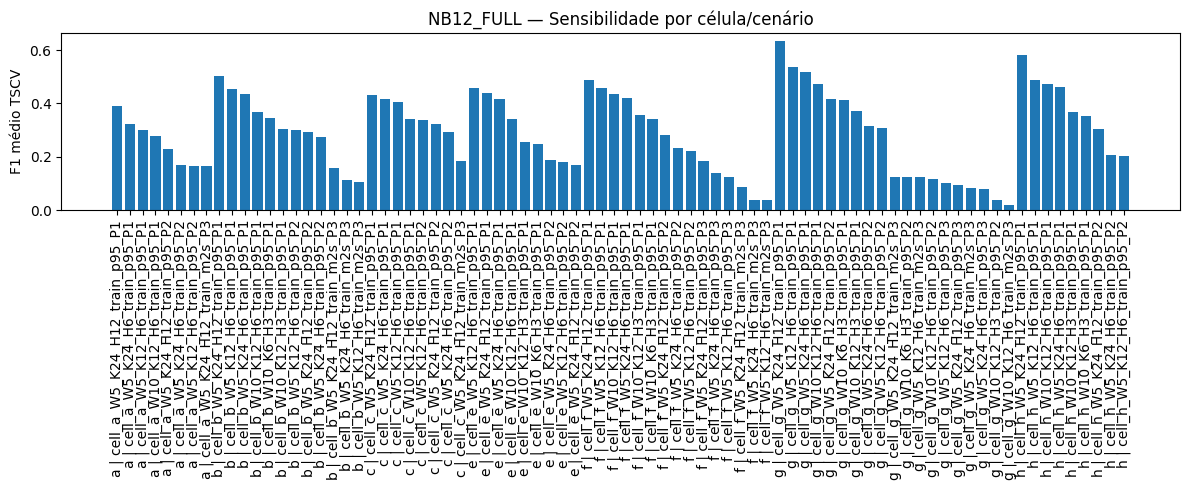

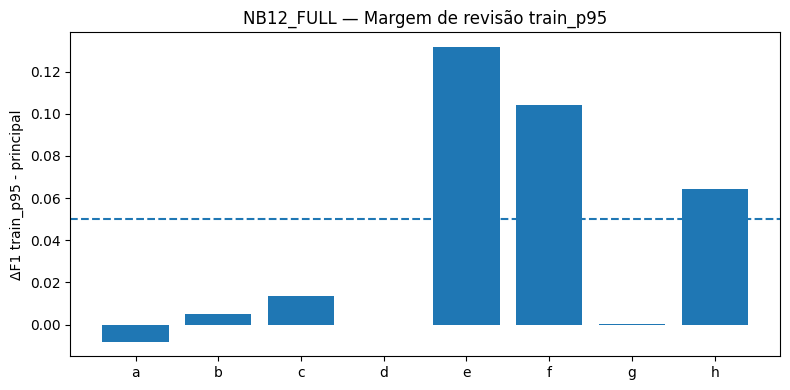

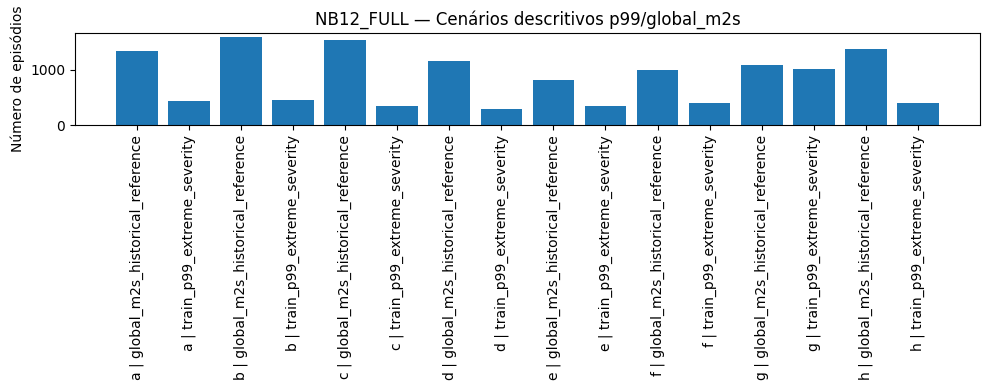


=== NB12_FULL — arquivos aggregate gerados ===


,artifact,path,exists
0,metrics_tscv_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
1,metrics_fixed_split_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
2,sensitivity_summary_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
3,sensitivity_aggregate,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
4,sensitivity_descriptive_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
5,modelability_by_cell_scenario,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
6,train_p95_review_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
7,winner_context_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
8,execution_errors_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True
9,scores_sensitivity_fixed_by_cell,/content/drive/MyDrive/Mestrado/04-reports/99_...,True



=== NB12_FULL — vencedor/contexto por célula ===


,cell_id,scenario_label,feature_set,model,features,f1_tscv_mean,selection_scope,fallback_used,fallback_reason,source
0,a,cell_a_W5_K24_H12_train_m2s_P1,temporal_core,logistic_regression,"[fail_rate, n_events, n_failed, n_machines, n_...",0.398095,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv
1,b,cell_b_W5_K24_H12_train_m2s_P1,temporal_core,hist_gradient_boosting,"[fail_rate, n_events, n_failed, n_machines, n_...",0.496409,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv
2,c,cell_c_W5_K24_H6_train_m2s_P1,temporal_core,hist_gradient_boosting,"[fail_rate, n_events, n_failed, n_machines, n_...",0.401552,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv
3,d,cell_d_W5_K24_H12_train_m2s_P2,raw_core,logistic_regression,"[fail_rate, n_events, n_failed, n_machines, n_...",0.425712,cell_winner_all_status_fallback,False,,11_FULL_metrics_summary_by_cell.csv
4,e,cell_e_W5_K12_H6_train_m2s_P1,temporal_core,hist_gradient_boosting,"[fail_rate, n_events, n_failed, n_machines, n_...",0.326230,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv
5,f,cell_f_W5_K24_H12_train_m2s_P1,temporal_core,logistic_regression,"[fail_rate, n_events, n_failed, n_machines, n_...",0.385708,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv
6,g,cell_g_W5_K24_H12_train_m2s_P1,temporal_core,hist_gradient_boosting,"[fail_rate, n_events, n_failed, n_machines, n_...",0.633126,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv
7,h,cell_h_W5_K24_H12_train_m2s_P1,temporal_core,logistic_regression,"[fail_rate, n_events, n_failed, n_machines, n_...",0.516797,cell_winner_modelable_only,False,,11_FULL_metrics_summary_by_cell.csv



=== NB12_FULL — modelabilidade por célula/cenário ===


...


=== NB12_FULL — validações de piloto ===


,check_name,status,value,detail
0,active_cells_non_empty,OK,8,"['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']"
1,nb11_winner_present,OK,1,/content/drive/MyDrive/Mestrado/04-reports/99_...
2,modelability_table_generated,OK,122,Tabela NB12_FULL de modelabilidade por célula/...
3,model_candidate_coverage,OK,80/122 (65.6%),Cobertura mínima esperada: 50%. Detecta aborto...
4,n_cells_with_modelable_sensitivity,OK,7,Células com ao menos um cenário de sensibilida...
5,n_cells_without_modelable_sensitivity,OK,1,Células que ficam apenas descritivas no NB12_F...
6,no_train_p99_supervised_metrics,OK,0,Cenários train_p99 devem permanecer descritivo...
7,train_p95_review_resolved_when_candidate_exists,OK,0,"Se há train_p95 nos candidatos, o review não p..."
8,aggregate_scopes_present,OK,"all_cells_including_descriptive,modelable_only",Escopos esperados: ['all_cells_including_descr...
9,no_canonical_output_prefix,OK,12_FULL_*,Todos os artefatos do NB12_FULL usam prefixo 1...



=== NB12_FULL — sumário final ===
{
  "notebook": "NB12_FULL_sensitivity_diagnostics",
  "executed_at": "2026-07-25 02:42:38",
  "active_cells": [
    "a",
    "b",
    "c",
    "d",
    "e",
    "f",
    "g",
    "h"
  ],
  "stage12_dir": "/content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/12_FULL_sensitivity",
  "upstream_stage10_dir": "/content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics",
  "upstream_stage11_aggregate_dir": "/content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/11_FULL_model_baselines/aggregate",
  "objective": "Verificar estabilidade das escolhas do NB10_FULL/NB11_FULL sob sensibilidade compacta por célula.",
  "policy": {
    "no_nb11_repetition": true,
    "no_wide_grid_search": true,
    "model_execution": "apenas vencedor do NB11_FULL por célula nos cenários sensitivity_only elegíveis",
    "p99_policy": "descriptive_only_no_model_execution",
    "global_m2s_policy": "historical_reference_no_model_exec

,relative_path,size_bytes,sha256
79,cell_g/12_FULL_execution_errors_cell_g.csv,952,7b8681a70e2229e68bce2f5c361fd20f560c71c98b38a6...
80,cell_g/12_FULL_modelability_by_scenario_cell_g...,4524,25dd20692702e1b5d79b48abf736494b230264d6d9f68d...
81,cell_g/12_FULL_scenario_selection_cell_g.json,2312,af04c932144ee8e1036a4bd9ebb14917fbf8c2c7b5b61a...
82,cell_g/12_FULL_scores_sensitivity_fixed_cell_g...,161923,8ce1717500721423bdb8639633e957a65eb9337a2d32f4...
83,cell_g/12_FULL_sensitivity_descriptive_cell_g.csv,8923,a540096196e3f72877e3ada770da4de73f1d60e964c6e9...
84,cell_g/12_FULL_sensitivity_metrics_fixed_split...,10102,edf51ee5b4d5044d615bf76ce421bf790ad5ed1fdbb12e...
85,cell_g/12_FULL_sensitivity_metrics_tscv_cell_g...,45450,e3e8e6352c37435e1a9d3b26812378d85611c630bc65ac...
86,cell_g/12_FULL_sensitivity_summary_cell_g.csv,7577,5ba1d5fb57c6f3d1d5a7d9cab2ea24faef3adbe77d4331...
87,cell_g/12_FULL_train_p95_review_cell_g.json,638,127421797c234f21572a18e71ffaeb256abd2522f12eb6...
88,cell_g/12_FULL_winner_context_cell_g.json,593,e6b8d54e48d237d72f7829fd76b98da9ee184077c2c7ed...


NB12_FULL finalizado em: 2026-07-25 02:42:38


In [1]:

# ============================================================
# NB12_FULL — Sensibilidade compacta e robustez por célula
#
# A etapa avalia cenários de sensibilidade do experimento FULL,
# preservando cell_id como unidade experimental, o corte temporal
# herdado e a governança que mantém TRAIN_M2S como referência.
# ============================================================

# ============================================================
# 0. Imports e configuração geral
# ============================================================

import os
import re
import json
import math
import shutil
import hashlib
import subprocess
import importlib
import warnings
import difflib
import traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS_TSCV = 5
FIXED_TRAIN_FRAC_REFERENCE = 0.80  # referência para validação leve; nunca usada para rederivar corte
DEFAULT_THRESHOLD = 0.50
REVIEW_DELTA_F1 = 0.05
MIN_MODEL_CANDIDATE_COVERAGE = 0.50
MIN_TRAIN_POSITIVES_FOR_MODELING = 30
MIN_TEST_POSITIVES_FOR_MODELING = 30
MIN_TSCV_SPLITS = 2

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("NB12_FULL iniciado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


# ============================================================
# 1. Bootstrap, caminhos do experimento FULL e travas de herança
# ============================================================

if not Path("/content/drive/MyDrive").exists():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível montar o Google Drive automaticamente.")
        print("[Bootstrap] Detalhe:", e)
else:
    print("[Bootstrap] Google Drive já montado.")

MYDRIVE_ROOT = Path("/content/drive/MyDrive")
DRIVE_ROOT = MYDRIVE_ROOT / "Mestrado"
REPO_DIR = DRIVE_ROOT / "PPCOMP_DM"
NOTEBOOKS_DIR = MYDRIVE_ROOT / "Colab Notebooks"
CANONICAL_NOTEBOOK = NOTEBOOKS_DIR / "12_sensitivity_diagnostics.ipynb"
FULL_NOTEBOOK = NOTEBOOKS_DIR / "12_sensitivity_diagnostics_FULL.ipynb"
GITHUB_REPO = "https://github.com/sergiocostaifes/PPCOMP_DM.git"

# O repositório é opcional para a execução e apoia a rastreabilidade por diff.
if REPO_DIR.exists():
    try:
        print("[Bootstrap] Atualizando repositório (git pull)...")
        subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=False)
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível atualizar via git pull:", e)
    try:
        os.chdir(str(REPO_DIR))
        if str(REPO_DIR) not in os.sys.path:
            os.sys.path.insert(0, str(REPO_DIR))
        importlib.invalidate_caches()
    except Exception as e:
        print("[Bootstrap] Aviso: não foi possível usar REPO_DIR como CWD:", e)

FULL_CELLS = list("abcdefgh")
ACTIVE_CELLS = FULL_CELLS[:]  # Para piloto: ACTIVE_CELLS = ["a"]
# ACTIVE_CELLS = ["a"]

FULL_MODEL_FACING_PARQUET = (
    DRIVE_ROOT
    / "02-datasets"
    / "99-full"
    / "03-model-facing"
    / "window_5min_series_allcells_model_facing_000000000000.parquet"
)
CANONICAL_WINDOW_5MIN_SERIES = DRIVE_ROOT / "02-datasets" / "03-features" / "window_5min_series.parquet"

FULL_REPORTS_DIR = DRIVE_ROOT / "04-reports" / "99_FULL_downstream"
STAGE10_DIR = FULL_REPORTS_DIR / "10_FULL_threshold_diagnostics"
STAGE11_DIR = FULL_REPORTS_DIR / "11_FULL_model_baselines"
STAGE11_AGG_DIR = STAGE11_DIR / "aggregate"
STAGE12_DIR = FULL_REPORTS_DIR / "12_FULL_sensitivity"
AGGREGATE_DIR = STAGE12_DIR / "aggregate"
FIGURES_DIR = AGGREGATE_DIR / "figures"
FIGURES_BY_CELL_DIR = AGGREGATE_DIR / "figures_by_cell"

for p in [FULL_REPORTS_DIR, STAGE12_DIR, AGGREGATE_DIR, FIGURES_DIR, FIGURES_BY_CELL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("DRIVE_ROOT       :", DRIVE_ROOT)
print("STAGE10_DIR      :", STAGE10_DIR)
print("STAGE11_AGG_DIR  :", STAGE11_AGG_DIR)
print("STAGE12_DIR      :", STAGE12_DIR)
print("AGGREGATE_DIR    :", AGGREGATE_DIR)
print("ACTIVE_CELLS     :", ACTIVE_CELLS)

assert "03-features" not in str(FULL_REPORTS_DIR), "FULL_REPORTS_DIR não pode apontar para 03-features."
assert FULL_MODEL_FACING_PARQUET != CANONICAL_WINDOW_5MIN_SERIES, "A entrada FULL não pode ser a série do protótipo Kaggle refinado."
assert STAGE10_DIR.exists(), f"Artefatos NB10_FULL não encontrados: {STAGE10_DIR}"
assert STAGE11_AGG_DIR.exists(), f"Aggregate do NB11_FULL não encontrado: {STAGE11_AGG_DIR}"

RAW_CORE_FEATURES = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_LOST_count",
]

TEMPORAL_CORE_FEATURES = RAW_CORE_FEATURES + [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]

raw_core = RAW_CORE_FEATURES[:]
temporal_core = TEMPORAL_CORE_FEATURES[:]

FORBIDDEN_FEATURE_PATTERNS = [
    "target",
    "label",
    "state",
    "during",
    "before",
    "after",
    "critical",
    "episode",
    "future",
    "horizon",
    "bucket_start_us",
    "bucket_id",
    "row_position",
    "split",
    "time",
    "timestamp",
]

FORBIDDEN_PREDICTORS = {
    "event_FAIL_count",
    "y",
    "y_nb11",
    "y_nb12",
    "target",
    "target_binary",
    "y_binary",
    "y_anticipation",
    "anticipation_target",
    "will_enter_during_h",
    "state",
    "episode_id",
    "is_critical",
    "has_complete_horizon",
    "has_complete_horizon_nb11",
    "has_complete_horizon_nb12",
    "eligible_supervised",
}

PRIMARY_THRESHOLD_FAMILY = "train_m2s"
PRIMARY_THRESHOLD_DISPLAY = "TRAIN_M2S"

assert "event_FAIL_count" not in raw_core
assert "event_FAIL_count" not in temporal_core
assert len(raw_core) == 6
assert len(temporal_core) == 13
assert len(raw_core) == len(set(raw_core))
assert len(temporal_core) == len(set(temporal_core))
assert not (set(raw_core) & FORBIDDEN_PREDICTORS)
assert not (set(temporal_core) & FORBIDDEN_PREDICTORS)

if FULL_MODEL_FACING_PARQUET.exists():
    try:
        df_cells_check = pd.read_parquet(FULL_MODEL_FACING_PARQUET, columns=["cell_id"])
        observed_cells = sorted(df_cells_check["cell_id"].dropna().astype(str).unique().tolist())
        assert observed_cells == FULL_CELLS, f"cell_id inesperado no Parquet FULL: {observed_cells}"
    except Exception as e:
        print("[NB12_FULL] Aviso: não foi possível checar cell_id no Parquet FULL:", e)
else:
    print(f"[NB12_FULL] Aviso: Parquet model-facing FULL não encontrado para checagem leve: {FULL_MODEL_FACING_PARQUET}")

RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")


def log(msg: str) -> None:
    print(f"[NB12_FULL_sensitivity] {msg}")


# ============================================================
# 2. Utilidades gerais
# ============================================================

def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(json_ready(obj), f, ensure_ascii=False, indent=2)


def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def json_ready(obj):
    """Converte objetos NumPy/Pandas/Path para JSON seguro."""
    if isinstance(obj, dict):
        return {str(k): json_ready(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [json_ready(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        val = float(obj)
        return None if np.isnan(val) else val
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    try:
        if pd.isna(obj):
            return None
    except Exception:
        pass
    return obj


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def build_artifact_manifest(root_dir: Path, out_file: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(root_dir.rglob("*")):
        if not p.is_file():
            continue
        if p == out_file:
            continue
        rows.append({
            "relative_path": str(p.relative_to(root_dir)).replace("\\", "/"),
            "size_bytes": int(p.stat().st_size),
            "sha256": sha256_file(p),
        })
    df = pd.DataFrame(rows)
    df.to_csv(out_file, index=False, encoding="utf-8")
    return df


def save_csv(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8")


def save_parquet(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)


# Esquemas mínimos esperados para CSVs por célula que podem ficar sem linhas.
# Objetivo: permitir leitura posterior com pd.read_csv mesmo quando uma célula
# não possui cenários supervisionados modeláveis, como ocorre em cell_d.
NB12_CELL_TSCV_COLUMNS = [
    "cell_id", "scenario_label", "W", "K", "H", "P", "threshold_kind", "threshold_family",
    "train_cutoff_idx", "train_cutoff_bucket_id", "cutoff_source", "n_supervised_rows",
    "n_train", "n_test", "n_positivos_train", "n_positivos_test", "positive_rate_train",
    "positive_rate_test", "status_modelagem", "is_modelable", "modelability_reason",
    "validation", "fold", "feature_set", "model", "winner_selection_scope", "winner_fallback_used",
    "nb11_reference_f1_tscv_mean", "n", "positive_rate", "threshold", "accuracy",
    "precision", "recall", "f1", "roc_auc", "average_precision", "brier", "tn", "fp",
    "fn", "tp", "false_alerts", "false_alerts_per_day",
]

NB12_CELL_FIXED_COLUMNS = [
    "cell_id", "scenario_label", "W", "K", "H", "P", "threshold_kind", "threshold_family",
    "train_cutoff_idx", "train_cutoff_bucket_id", "cutoff_source", "n_supervised_rows",
    "n_train", "n_test", "n_positivos_train", "n_positivos_test", "positive_rate_train",
    "positive_rate_test", "status_modelagem", "is_modelable", "modelability_reason",
    "validation", "feature_set", "model", "winner_selection_scope", "winner_fallback_used",
    "nb11_reference_f1_tscv_mean", "n", "positive_rate", "threshold", "accuracy",
    "precision", "recall", "f1", "roc_auc", "average_precision", "brier", "tn", "fp",
    "fn", "tp", "false_alerts", "false_alerts_per_day",
]

NB12_CELL_SUMMARY_COLUMNS = [
    "cell_id", "scenario_label", "W", "K", "H", "P", "threshold_kind", "threshold_family",
    "feature_set", "model", "status_modelagem", "is_modelable", "winner_selection_scope",
    "winner_fallback_used", "n_folds_valid", "n_rows_test_total", "positive_rate_test_mean",
    "f1_tscv_mean", "f1_tscv_std", "recall_tscv_mean", "precision_tscv_mean",
    "roc_auc_tscv_mean", "average_precision_tscv_mean", "brier_tscv_mean",
    "false_alerts_per_day_mean", "nb11_reference_f1_tscv_mean", "n_positivos_train",
    "n_positivos_test", "delta_f1_vs_nb11_cell_reference",
]


def save_csv_with_header_when_empty(df: pd.DataFrame, path: Path, expected_columns: list) -> None:
    """Grava CSV normal; se vazio, grava 0 linhas com cabeçalho esperado."""
    if df is None:
        df = pd.DataFrame()
    if df.empty:
        df = pd.DataFrame(columns=expected_columns)
    save_csv(df, path)


def find_existing(paths, required=True, label="arquivo"):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    if required:
        raise FileNotFoundError(f"{label} não encontrado em: " + " | ".join(str(p) for p in paths))
    return None


# ============================================================
# 3. Carregamento dos artefatos NB11_FULL aggregate
# ============================================================

PATH_NB11_WINNER = find_existing([STAGE11_AGG_DIR / "11_FULL_winner_model.json"], required=True, label="winner NB11_FULL")
PATH_NB11_SUMMARY = find_existing([STAGE11_AGG_DIR / "11_FULL_nb11_summary.json"], required=False, label="summary NB11_FULL")
PATH_NB11_METRICS_SUMMARY = find_existing([STAGE11_AGG_DIR / "11_FULL_metrics_summary_by_cell.csv"], required=True, label="metrics NB11_FULL")
PATH_NB11_BASELINES_SUMMARY = find_existing([STAGE11_AGG_DIR / "11_FULL_baselines_summary_by_cell.csv"], required=False, label="baselines NB11_FULL")
PATH_NB11_MODELABILITY = find_existing([STAGE11_AGG_DIR / "11_FULL_modelability_by_cell_scenario.csv"], required=False, label="modelability NB11_FULL")
PATH_NB11_METRICS_AGGREGATE = find_existing([STAGE11_AGG_DIR / "11_FULL_metrics_aggregate.csv"], required=False, label="metrics aggregate NB11_FULL")
PATH_NB11_FEATURE_SETS = find_existing([STAGE11_AGG_DIR / "11_FULL_feature_sets.json"], required=False, label="feature sets NB11_FULL")

winner_global = read_json(PATH_NB11_WINNER)
nb11_summary = read_json(PATH_NB11_SUMMARY) if PATH_NB11_SUMMARY else {}
df_nb11_metrics_summary = pd.read_csv(PATH_NB11_METRICS_SUMMARY)
df_nb11_baselines_summary = pd.read_csv(PATH_NB11_BASELINES_SUMMARY) if PATH_NB11_BASELINES_SUMMARY else pd.DataFrame()
df_nb11_modelability = pd.read_csv(PATH_NB11_MODELABILITY) if PATH_NB11_MODELABILITY else pd.DataFrame()
df_nb11_metrics_aggregate = pd.read_csv(PATH_NB11_METRICS_AGGREGATE) if PATH_NB11_METRICS_AGGREGATE else pd.DataFrame()
feature_sets_from_nb11 = read_json(PATH_NB11_FEATURE_SETS) if PATH_NB11_FEATURE_SETS else {}

print("winner_global:")
print(json.dumps(json_ready(winner_global), ensure_ascii=False, indent=2))
print("df_nb11_metrics_summary:", df_nb11_metrics_summary.shape)
print("df_nb11_modelability:", df_nb11_modelability.shape)


# ============================================================
# 4. Funções de parsing, inferência e seleção do vencedor
# ============================================================

def infer_scenario_column(df: pd.DataFrame):
    candidates = ["scenario_label", "scenario", "scenario_id", "config_label", "label"]
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError("Não foi possível identificar coluna de cenário.")


def infer_decision_column(df: pd.DataFrame):
    candidates = ["decision", "category", "decision_category", "promotion", "status", "nb11_decision", "action"]
    for c in candidates:
        if c in df.columns:
            vals = df[c].astype(str).str.lower()
            if vals.str.contains("sensitivity_only|advance_to_nb11|historical_reference|do_not_advance", na=False).any():
                return c
    for c in df.columns:
        if df[c].dtype == "object":
            vals = df[c].astype(str).str.lower()
            if vals.str.contains("sensitivity_only|advance_to_nb11|historical_reference|do_not_advance", na=False).any():
                return c
    raise ValueError("Não foi possível identificar coluna de decisão/categoria no NB10_FULL.")


def infer_episode_columns(df_episodes: pd.DataFrame):
    start_candidates = ["start_bucket_id", "episode_start_bucket_id", "start_bucket", "bucket_start", "start"]
    end_candidates = ["end_bucket_id", "episode_end_bucket_id", "end_bucket", "bucket_end", "end"]
    start_col = next((c for c in start_candidates if c in df_episodes.columns), None)
    end_col = next((c for c in end_candidates if c in df_episodes.columns), None)
    if start_col is None or end_col is None:
        raise ValueError("Não foi possível inferir colunas de início/fim de episódio.")
    return start_col, end_col


def threshold_family_robusta(label):
    """Classifica a família de limiar a partir do rótulo do cenário.

    p99 e global_m2s permanecem descritivos; train_p95 participa da análise
    de sensibilidade; TRAIN_M2S permanece a referência principal.
    """
    s = str(label).lower()
    for fam in ["train_p95", "train_p99", "global_m2s", "train_m2s"]:
        if fam in s:
            return fam
    return "unknown"


def parse_scenario_label(label):
    label = str(label)
    # Labels reais: cell_g_W5_K24_H12_train_m2s_P1
    # Ordem real: W/K/H/<threshold>/P, com prefixo cell_<id>_ opcional.
    pattern = r"(?:cell_[a-z]+_)?W(?P<W>\d+)_K(?P<K>\d+)_H(?P<H>\d+)_(?P<threshold>.+?)_P(?P<P>\d+)$"
    m = re.search(pattern, label)
    if not m:
        fam = threshold_family_robusta(label)
        return {
            "scenario_label": label,
            "W": np.nan,
            "K": np.nan,
            "H": np.nan,
            "P": np.nan,
            "threshold_kind": fam.upper() if fam != "unknown" else "unknown",
            "threshold_family": fam,
        }
    threshold_family = threshold_family_robusta(m.group("threshold"))
    if threshold_family == "unknown":
        threshold_family = str(m.group("threshold")).lower()
    return {
        "scenario_label": label,
        "W": int(m.group("W")),
        "K": int(m.group("K")),
        "H": int(m.group("H")),
        "P": int(m.group("P")),
        "threshold_kind": str(m.group("threshold")).upper(),
        "threshold_family": threshold_family,
    }


def enrich_with_parsed_scenario(df: pd.DataFrame, scenario_col: str) -> pd.DataFrame:
    if df is None or df.empty:
        return df.copy() if df is not None else pd.DataFrame()
    parsed = df[scenario_col].apply(parse_scenario_label).apply(pd.Series)
    out = df.copy()
    for c in parsed.columns:
        if c not in out.columns:
            out[c] = parsed[c]
    return out


def parse_features_value(value):
    if isinstance(value, list):
        return [str(v) for v in value]
    if isinstance(value, tuple):
        return [str(v) for v in value]
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    s = str(value).strip()
    if not s:
        return []
    if s.startswith("[") and s.endswith("]"):
        try:
            parsed = json.loads(s.replace("'", '"'))
            if isinstance(parsed, list):
                return [str(v) for v in parsed]
        except Exception:
            pass
    if "|" in s:
        return [x.strip() for x in s.split("|") if x.strip()]
    if "," in s:
        return [x.strip() for x in s.split(",") if x.strip()]
    return [s]



def normalize_feature_set_name(feature_set: str) -> str:
    name = str(feature_set).strip()
    legacy_name = "raw" + "_7"
    if name == legacy_name:
        raise AssertionError(
            "O conjunto legado de sete atributos não integra a linhagem ativa; "
            "use raw_core com 6 atributos."
        )
    return name


def validate_winner_feature_contract(winner_ctx: dict, context: str) -> None:
    feature_set = normalize_feature_set_name(winner_ctx.get("feature_set", ""))
    features = [str(c) for c in winner_ctx.get("features", [])]

    if not features:
        raise AssertionError(f"{context}: lista de atributos vazia.")
    if len(features) != len(set(features)):
        raise AssertionError(f"{context}: nomes repetidos no vetor de preditores.")
    if "event_FAIL_count" in features:
        raise AssertionError(f"{context}: event_FAIL_count não pode integrar os preditores.")

    forbidden_names = sorted(set(features) & FORBIDDEN_PREDICTORS)
    forbidden_patterns = sorted({
        col
        for col in features
        if any(pattern in col.lower() for pattern in FORBIDDEN_FEATURE_PATTERNS)
    })
    if forbidden_names or forbidden_patterns:
        raise AssertionError(
            f"{context}: atributos proibidos detectados; "
            f"nomes={forbidden_names}; padrões={forbidden_patterns}"
        )

    expected = {
        "raw_core": RAW_CORE_FEATURES,
        "temporal_core": TEMPORAL_CORE_FEATURES,
    }
    if feature_set in expected:
        required = expected[feature_set]
        if len(features) != len(required) or set(features) != set(required):
            raise AssertionError(
                f"{context}: contrato de {feature_set} inválido; "
                f"esperado={required}; recebido={features}"
            )


def validate_active_feature_dataframe(
    df: pd.DataFrame,
    features: list,
    feature_set: str,
    context: str,
) -> None:
    validate_winner_feature_contract(
        {"feature_set": feature_set, "features": features},
        context=context,
    )

    missing = [c for c in features if c not in df.columns]
    if missing:
        raise AssertionError(f"{context}: atributos ausentes no dataframe ativo: {missing}")

    non_numeric = [c for c in features if not pd.api.types.is_numeric_dtype(df[c])]
    if non_numeric:
        raise AssertionError(f"{context}: atributos ativos não numéricos: {non_numeric}")

    if {"n_failed", "event_FAIL_count"}.issubset(df.columns):
        left = pd.to_numeric(df["n_failed"], errors="coerce").fillna(0.0)
        right = pd.to_numeric(df["event_FAIL_count"], errors="coerce").fillna(0.0)
        if not left.equals(right):
            raise AssertionError(
                f"{context}: divergência entre n_failed e event_FAIL_count."
            )

    duplicate_pairs = []
    for i, col_a in enumerate(features):
        for col_b in features[i + 1:]:
            if df[col_a].equals(df[col_b]):
                duplicate_pairs.append((col_a, col_b))
    if duplicate_pairs:
        raise AssertionError(
            f"{context}: duplicidades exatas não justificadas nos preditores: "
            f"{duplicate_pairs}"
        )


def _to_bool_series(s):
    if s is None:
        return pd.Series(dtype=bool)
    if s.dtype == bool:
        return s.fillna(False)
    return s.astype(str).str.lower().isin(["true", "1", "sim", "yes", "y", "modelavel"])


def select_nb11_winner_for_cell(cell_id: str) -> dict:
    """Seleciona o vencedor do NB11_FULL para a célula.

    Preferência metodológica:
      1. vencedor TSCV da própria célula e modelável;
      2. vencedor TSCV da própria célula, mesmo sem flag modelável;
      3. vencedor global do NB11_FULL como fallback explícito.
    """
    df = df_nb11_metrics_summary.copy()
    if "cell_id" not in df.columns:
        raise ValueError("11_FULL_metrics_summary_by_cell.csv sem cell_id.")
    d = df[df["cell_id"].astype(str) == str(cell_id)].copy()
    fallback_used = False
    fallback_reason = ""

    if not d.empty and "is_winner_tscv" in d.columns:
        d_w = d[_to_bool_series(d["is_winner_tscv"])].copy()
    else:
        d_w = pd.DataFrame()

    if not d_w.empty and "is_modelable" in d_w.columns:
        d_modelable = d_w[_to_bool_series(d_w["is_modelable"])].copy()
    else:
        d_modelable = pd.DataFrame()

    if not d_modelable.empty:
        candidates = d_modelable
        selection_scope = "cell_winner_modelable_only"
    elif not d_w.empty:
        candidates = d_w
        selection_scope = "cell_winner_all_status_fallback"
    elif not d.empty:
        sort_cols = [c for c in ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"] if c in d.columns]
        candidates = d.sort_values(sort_cols, ascending=[False] * len(sort_cols)) if sort_cols else d
        selection_scope = "cell_best_available_fallback"
        fallback_used = True
        fallback_reason = "cell_id sem linha is_winner_tscv; selecionado melhor disponível por métrica."
    else:
        candidates = pd.DataFrame()
        selection_scope = "global_winner_fallback"
        fallback_used = True
        fallback_reason = "cell_id sem métricas no NB11_FULL; usado winner global."

    if not candidates.empty:
        sort_cols = [c for c in ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"] if c in candidates.columns]
        row = candidates.sort_values(sort_cols, ascending=[False] * len(sort_cols)).iloc[0] if sort_cols else candidates.iloc[0]
        feature_set = str(row.get("feature_set", winner_global.get("feature_set", "temporal_core")))
        model = str(row.get("model", winner_global.get("model", "logistic_regression")))
        features = parse_features_value(row.get("features", None))
        if not features and feature_set in feature_sets_from_nb11:
            features = parse_features_value(feature_sets_from_nb11[feature_set])
        if not features:
            features = parse_features_value(winner_global.get("features", []))
        f1_ref = float(row.get("f1_tscv_mean", np.nan)) if "f1_tscv_mean" in row.index else np.nan
        scenario_label = str(row.get("scenario_label", winner_global.get("scenario_label", "")))
        out = {
            "cell_id": str(cell_id),
            "scenario_label": scenario_label,
            "feature_set": feature_set,
            "model": model,
            "features": features,
            "f1_tscv_mean": f1_ref,
            "selection_scope": selection_scope,
            "fallback_used": fallback_used,
            "fallback_reason": fallback_reason,
            "source": "11_FULL_metrics_summary_by_cell.csv",
        }
    else:
        out = {
            "cell_id": str(cell_id),
            "scenario_label": str(winner_global.get("scenario_label", "")),
            "feature_set": str(winner_global.get("feature_set", "temporal_core")),
            "model": str(winner_global.get("model", "logistic_regression")),
            "features": parse_features_value(winner_global.get("features", [])),
            "f1_tscv_mean": float(winner_global.get("f1_tscv_mean", np.nan)),
            "selection_scope": selection_scope,
            "fallback_used": fallback_used,
            "fallback_reason": fallback_reason,
            "source": "11_FULL_winner_model.json",
        }

    if not out["features"]:
        raise ValueError(f"Não foi possível resolver os atributos do vencedor NB11_FULL para cell_{cell_id}.")
    out["feature_set"] = normalize_feature_set_name(out["feature_set"])
    validate_winner_feature_contract(
        out,
        context=f"cell_{cell_id}::winner_nb11_full",
    )
    return out


# ============================================================
# 5. Métricas, features causais e alvo supervisionado
# ============================================================

def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def safe_brier(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(y_true) == 0:
        return np.nan
    return brier_score_loss(y_true, np.clip(y_score, 0, 1))


def binary_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    if len(y_true) == 0:
        return {"n": 0, "positive_rate": np.nan, "threshold": threshold, "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan, "roc_auc": np.nan, "average_precision": np.nan, "brier": np.nan, "tn": 0, "fp": 0, "fn": 0, "tp": 0}
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    auc = safe_auc(y_true, y_score)
    ap = safe_ap(y_true, y_score)
    brier = safe_brier(y_true, y_score)
    return {
        "n": int(len(y_true)),
        "positive_rate": float(np.mean(y_true)),
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(auc) if not np.isnan(auc) else np.nan,
        "average_precision": float(ap) if not np.isnan(ap) else np.nan,
        "brier": float(brier) if not np.isnan(brier) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def false_alerts_per_day(y_true, y_score, window_minutes, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    false_alerts = int(((y_pred == 1) & (y_true == 0)).sum())
    total_days = (len(y_true) * window_minutes) / (60 * 24)
    return {
        "false_alerts": false_alerts,
        "false_alerts_per_day": float(false_alerts / total_days) if total_days > 0 else np.nan,
    }


def add_causal_temporal_features(df: pd.DataFrame, window_minutes: int):
    if "fail_rate" not in df.columns:
        raise ValueError("fail_rate é necessária para criar atributos temporais causais.")
    sort_cols = [c for c in ["bucket_id", "row_position"] if c in df.columns]
    df = df.sort_values(sort_cols if sort_cols else df.index.name).copy()
    df["lag_1"] = df["fail_rate"].shift(1)
    df["lag_2"] = df["fail_rate"].shift(2)
    df["lag_3"] = df["fail_rate"].shift(3)
    rolling_window = max(int(round(60 / window_minutes)), 1)
    df["rolling_mean_1h"] = df["fail_rate"].shift(1).rolling(window=rolling_window, min_periods=1).mean()
    df["rolling_std_1h"] = df["fail_rate"].shift(1).rolling(window=rolling_window, min_periods=2).std(ddof=0)
    previous = df["fail_rate"].shift(1)
    df["pct_change"] = (df["fail_rate"] - previous) / previous.replace(0, np.nan)
    expanding_mean = df["fail_rate"].shift(1).expanding(min_periods=2).mean()
    expanding_std = df["fail_rate"].shift(1).expanding(min_periods=2).std(ddof=0)
    df["zscore_expanding"] = (df["fail_rate"] - expanding_mean) / expanding_std.replace(0, np.nan)
    temporal_cols = ["lag_1", "lag_2", "lag_3", "rolling_mean_1h", "rolling_std_1h", "pct_change", "zscore_expanding"]
    df[temporal_cols] = df[temporal_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return df


def get_h_windows_from_label(label, fallback=12):
    parsed = parse_scenario_label(label)
    return fallback if pd.isna(parsed["H"]) else int(parsed["H"])


def get_window_minutes_from_label(label, fallback=5):
    parsed = parse_scenario_label(label)
    return fallback if pd.isna(parsed["W"]) else int(parsed["W"])


def coerce_binary_target(series, context: str, fill_missing: bool = False) -> pd.Series:
    """Converte o alvo binário para inteiro com validação de finitude.

    Para linhas supervisionadas elegíveis, valores não finitos constituem
    anomalia estrutural e interrompem a avaliação.
    """
    s = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    n_bad = int(s.isna().sum())
    if n_bad:
        if not fill_missing:
            raise ValueError(
                f"{context}: alvo contém {n_bad} valores não finitos em linhas elegíveis/supervisionadas; "
                "abortar, não preencher com 0."
            )
        log(f"Aviso: {context}: {n_bad} valores não finitos no alvo; preenchendo como 0.")
        s = s.fillna(0)
    return s.clip(lower=0, upper=1).round().astype(int)


def ensure_target_column(df: pd.DataFrame, scenario_label: str):
    """Constrói y_nb12 com a semântica prospectiva adotada no NB11_FULL.

    Quando os artefatos de entrada não registram explicitamente a completude
    do horizonte, a elegibilidade é derivada pela posição temporal e as últimas
    H janelas são removidas. Valores não finitos remanescentes interrompem o cenário.
    """
    df = df.copy()
    target_candidates = [
        "y",
        "target",
        "target_binary",
        "y_binary",
        "y_anticipation",
        "anticipation_target",
        "will_enter_during_h",
        "y_nb11",
    ]

    for c in target_candidates:
        if c in df.columns:
            sort_cols = [col for col in ["row_position", "bucket_id"] if col in df.columns]
            if sort_cols:
                df = df.sort_values(sort_cols).reset_index(drop=True).copy()
            else:
                df = df.reset_index(drop=True).copy()

            horizon_cols = [
                hcol for hcol in [
                    "has_complete_horizon",
                    "complete_horizon",
                    "has_complete_horizon_nb11",
                    "eligible_supervised",
                ]
                if hcol in df.columns
            ]

            if not horizon_cols:
                h_windows = get_h_windows_from_label(scenario_label, fallback=12)
                df["has_complete_horizon_nb12"] = False
                if len(df) > h_windows:
                    df.loc[: len(df) - h_windows - 1, "has_complete_horizon_nb12"] = True
                horizon_cols = ["has_complete_horizon_nb12"]

            # Restrição supervisionada prospectiva: estado atual antes da criticidade.
            if "state" in df.columns:
                df = df[df["state"].astype(str).isin(["NORMAL", "BEFORE"])].copy()

            for hcol in horizon_cols:
                df = df[df[hcol].fillna(False).astype(bool)].copy()

            # Só agora converte; alvo não-finito remanescente é erro estrutural.
            df["y_nb12"] = coerce_binary_target(
                df[c],
                context=f"{scenario_label}::{c}",
                fill_missing=False,
            )
            return df

    if "state" not in df.columns:
        raise ValueError("Nenhum alvo encontrado e coluna state ausente.")
    h_windows = get_h_windows_from_label(scenario_label, fallback=12)
    sort_cols = [c for c in ["row_position", "bucket_id"] if c in df.columns]
    df = df.sort_values(sort_cols).reset_index(drop=True).copy() if sort_cols else df.reset_index(drop=True).copy()
    states = df["state"].astype(str).values
    during = states == "DURING"
    y = np.zeros(len(df), dtype=bool)
    for step in range(1, h_windows + 1):
        shifted = np.zeros(len(df), dtype=bool)
        shifted[:-step] = during[step:]
        y = np.logical_or(y, shifted)
    df["y_nb12"] = y.astype(int)
    df["has_complete_horizon_nb12"] = False
    if len(df) > h_windows:
        df.loc[: len(df) - h_windows - 1, "has_complete_horizon_nb12"] = True
    df = df[df["state"].astype(str).isin(["NORMAL", "BEFORE"]) & df["has_complete_horizon_nb12"]].copy()
    return df


# ============================================================
# 6. Split herdado e modelabilidade por cenário
# ============================================================

def scenario_to_dict_list(obj) -> list:
    if obj is None:
        return []
    if isinstance(obj, list):
        return [x for x in obj if isinstance(x, dict)]
    if isinstance(obj, dict):
        for key in ["advanced_to_nb11", "advanced_scenarios", "scenarios", "selected_scenarios"]:
            if key in obj and isinstance(obj[key], list):
                return [x for x in obj[key] if isinstance(x, dict)]
        return [obj]
    return []


def sanitize_row_position_inplace(df: pd.DataFrame, scenario_label: str) -> pd.DataFrame:
    df = df.copy()
    sort_col = "bucket_id" if "bucket_id" in df.columns else None
    if "row_position" not in df.columns:
        if sort_col:
            df = df.sort_values(sort_col).copy()
        df["row_position"] = np.arange(len(df), dtype=int)
        log(f"Aviso: {scenario_label}: row_position ausente; reconstruída pela ordem temporal somente para aplicar corte herdado.")
        return df
    row_pos = pd.to_numeric(df["row_position"], errors="coerce")
    if row_pos.isna().any() or not np.isfinite(row_pos.fillna(0)).all():
        n_bad = int(row_pos.isna().sum())
        if sort_col:
            ordered_idx = df.sort_values(sort_col).index
        else:
            ordered_idx = df.index
        derived = pd.Series(np.arange(len(df), dtype=int), index=ordered_idx).reindex(df.index)
        row_pos = row_pos.fillna(derived)
        log(f"Aviso: {scenario_label}: {n_bad} row_position não finitos; recompostos pela ordem temporal.")
    df["row_position"] = row_pos.astype(int)
    return df


def _extract_cutoff_from_mapping(obj) -> tuple:
    if not isinstance(obj, dict):
        return None, None
    idx = obj.get("train_cutoff_idx", None)
    bid = obj.get("train_cutoff_bucket_id", None)
    try:
        idx_val = int(idx) if idx is not None and not pd.isna(idx) else None
    except Exception:
        idx_val = None
    try:
        bid_val = int(bid) if bid is not None and not pd.isna(bid) else None
    except Exception:
        bid_val = None
    return idx_val, bid_val


def resolve_inherited_cutoff(df_states_scenario: pd.DataFrame, decision_row: dict, scenario_dict: dict, scenario_label: str) -> tuple:
    """Resolve train_cutoff_idx/bucket_id sem recalcular por fração."""
    sources = []

    idx, bid = _extract_cutoff_from_mapping(decision_row)
    if idx is not None and bid is not None:
        sources.append(("decision_row", idx, bid))

    idx, bid = _extract_cutoff_from_mapping(scenario_dict)
    if idx is not None and bid is not None:
        sources.append(("advanced_json_or_scenario_dict", idx, bid))

    for idx_col, bid_col in [
        ("train_cutoff_idx", "train_cutoff_bucket_id"),
        ("cutoff_idx", "cutoff_bucket_id"),
    ]:
        if idx_col in df_states_scenario.columns and bid_col in df_states_scenario.columns:
            idx_vals = pd.to_numeric(df_states_scenario[idx_col], errors="coerce").dropna().unique()
            bid_vals = pd.to_numeric(df_states_scenario[bid_col], errors="coerce").dropna().unique()
            if len(idx_vals) > 0 and len(bid_vals) > 0:
                sources.append((f"states_columns:{idx_col}/{bid_col}", int(idx_vals[0]), int(bid_vals[0])))

    if not sources:
        raise AssertionError(
            f"{scenario_label}: train_cutoff_idx/train_cutoff_bucket_id ausentes. "
            "NB12_FULL deve abortar; não recalcular o split por fração."
        )

    source, cutoff_idx, cutoff_bucket_id = sources[0]
    return int(cutoff_idx), int(cutoff_bucket_id), source


def attach_inherited_split(df: pd.DataFrame, cutoff_idx: int, scenario_label: str) -> pd.DataFrame:
    df = sanitize_row_position_inplace(df, scenario_label)
    df["split"] = np.where(df["row_position"].astype(int) < int(cutoff_idx), "train", "test")
    if df["split"].nunique() < 2:
        log(f"Aviso: {scenario_label}: split herdado gerou apenas {df['split'].unique().tolist()} após filtros supervisionados.")
    return df


def compute_modelability_info(df_prepared: pd.DataFrame, cell_id: str, scenario_label: str, cutoff_idx: int, cutoff_bucket_id: int, cutoff_source: str) -> dict:
    y = pd.to_numeric(df_prepared.get("y_nb12", pd.Series(dtype=int)), errors="coerce").fillna(0).astype(int)
    train_mask = df_prepared["split"].astype(str).eq("train") if "split" in df_prepared.columns else pd.Series(False, index=df_prepared.index)
    test_mask = df_prepared["split"].astype(str).eq("test") if "split" in df_prepared.columns else pd.Series(False, index=df_prepared.index)
    n_pos_train = int(y[train_mask].sum()) if len(y) else 0
    n_pos_test = int(y[test_mask].sum()) if len(y) else 0
    n_train = int(train_mask.sum())
    n_test = int(test_mask.sum())
    is_modelable = bool(n_pos_train >= MIN_TRAIN_POSITIVES_FOR_MODELING and n_pos_test >= MIN_TEST_POSITIVES_FOR_MODELING and n_train > 0 and n_test > 0)
    status = "modelavel" if is_modelable else "descritiva"
    reason = (
        "suporte mínimo train/test atendido"
        if is_modelable
        else f"suporte insuficiente: pos_train={n_pos_train}, pos_test={n_pos_test}, min_train={MIN_TRAIN_POSITIVES_FOR_MODELING}, min_test={MIN_TEST_POSITIVES_FOR_MODELING}"
    )
    parsed = parse_scenario_label(scenario_label)
    return {
        "cell_id": str(cell_id),
        "scenario_label": str(scenario_label),
        **parsed,
        "train_cutoff_idx": int(cutoff_idx),
        "train_cutoff_bucket_id": int(cutoff_bucket_id),
        "cutoff_source": str(cutoff_source),
        "n_supervised_rows": int(len(df_prepared)),
        "n_train": n_train,
        "n_test": n_test,
        "n_positivos_train": n_pos_train,
        "n_positivos_test": n_pos_test,
        "positive_rate_train": float(y[train_mask].mean()) if n_train else np.nan,
        "positive_rate_test": float(y[test_mask].mean()) if n_test else np.nan,
        "status_modelagem": status,
        "is_modelable": is_modelable,
        "modelability_reason": reason,
    }


# ============================================================
# 7. Modelo vencedor do NB11_FULL
# ============================================================

def make_estimator_from_winner(winner_dict):
    model_name = str(winner_dict.get("model", "logistic_regression"))
    if model_name == "logistic_regression":
        return Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE, solver="lbfgs")),
            ]
        )
    if model_name == "random_forest":
        return RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced_subsample")
    if model_name == "hist_gradient_boosting":
        return HistGradientBoostingClassifier(max_iter=200, early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE)
    raise ValueError(f"Modelo vencedor não suportado no NB12_FULL: {model_name}")


def compute_sample_weight_balanced(y):
    y = np.asarray(y).astype(int)
    n = len(y)
    classes, counts = np.unique(y, return_counts=True)
    weights = np.ones(n, dtype=float)
    for cls, cnt in zip(classes, counts):
        weights[y == cls] = n / (len(classes) * cnt)
    return weights


def fit_winner_model(estimator, model_name, X_train, y_train):
    est = clone(estimator)
    if len(np.unique(y_train)) < 2:
        raise ValueError("Treino com classe única; não é defensável ajustar modelo supervisionado.")
    if model_name == "hist_gradient_boosting":
        sw = compute_sample_weight_balanced(y_train)
        est.fit(X_train, y_train, sample_weight=sw)
    else:
        est.fit(X_train, y_train)
    return est


def predict_score(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        raw = estimator.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))
    return estimator.predict(X).astype(float)


# ============================================================
# 8. Entradas NB10_FULL por célula
# ============================================================

def resolve_nb10_cell_files(cell_id: str) -> dict:
    cell_dir = STAGE10_DIR / f"cell_{cell_id}"
    files = {
        "advanced_json": cell_dir / f"10_FULL_advanced_to_nb11_cell_{cell_id}.json",
        "states_parquet": cell_dir / f"10_FULL_scenario_series_states_cell_{cell_id}.parquet",
        "episodes_parquet": cell_dir / f"10_FULL_scenario_episodes_cell_{cell_id}.parquet",
        "decisions_csv": cell_dir / f"10_FULL_scenario_decisions_cell_{cell_id}.csv",
    }
    missing_required = [str(files[k]) for k in ["states_parquet", "episodes_parquet", "decisions_csv"] if not files[k].exists()]
    if missing_required:
        raise FileNotFoundError(f"Arquivos esperados do NB10_FULL não encontrados para cell_{cell_id}:\n" + "\n".join(missing_required))
    if not files["advanced_json"].exists():
        log(f"Aviso: advanced_json ausente para cell_{cell_id}; cutoffs deverão existir em decisions/states.")
    return files


def load_nb10_cell_inputs(cell_id: str) -> dict:
    files = resolve_nb10_cell_files(cell_id)
    advanced_raw = read_json(files["advanced_json"]) if files["advanced_json"].exists() else None
    advanced_scenarios = scenario_to_dict_list(advanced_raw)
    advanced_lookup = {str(s.get("scenario_label", s.get("scenario_id", ""))): s for s in advanced_scenarios if isinstance(s, dict)}

    df_states = pd.read_parquet(files["states_parquet"])
    df_episodes = pd.read_parquet(files["episodes_parquet"])
    df_decisions = pd.read_csv(files["decisions_csv"])

    if "cell_id" not in df_states.columns:
        df_states["cell_id"] = cell_id
    if not df_episodes.empty and "cell_id" not in df_episodes.columns:
        df_episodes["cell_id"] = cell_id
    if "cell_id" not in df_decisions.columns:
        df_decisions["cell_id"] = cell_id

    observed_states = sorted(df_states["cell_id"].dropna().astype(str).unique().tolist())
    assert observed_states == [cell_id], f"states NB10_FULL da cell_{cell_id} contém células inesperadas: {observed_states}"
    if not df_episodes.empty:
        observed_eps = sorted(df_episodes["cell_id"].dropna().astype(str).unique().tolist())
        assert observed_eps == [cell_id], f"episodes NB10_FULL da cell_{cell_id} contém células inesperadas: {observed_eps}"

    scenario_col_states = infer_scenario_column(df_states)
    scenario_col_decisions = infer_scenario_column(df_decisions)
    scenario_col_episodes = infer_scenario_column(df_episodes) if not df_episodes.empty else scenario_col_states
    decision_col = infer_decision_column(df_decisions)
    episode_start_col, episode_end_col = (None, None)
    if not df_episodes.empty:
        episode_start_col, episode_end_col = infer_episode_columns(df_episodes)

    df_decisions = enrich_with_parsed_scenario(df_decisions, scenario_col_decisions)
    df_states = enrich_with_parsed_scenario(df_states, scenario_col_states)
    if not df_episodes.empty:
        df_episodes = enrich_with_parsed_scenario(df_episodes, scenario_col_episodes)

    return {
        "cell_id": cell_id,
        "files": files,
        "advanced_lookup": advanced_lookup,
        "df_states_all": df_states,
        "df_episodes_all": df_episodes,
        "df_decisions": df_decisions,
        "scenario_col_states": scenario_col_states,
        "scenario_col_decisions": scenario_col_decisions,
        "scenario_col_episodes": scenario_col_episodes,
        "decision_col": decision_col,
        "episode_start_col": episode_start_col,
        "episode_end_col": episode_end_col,
    }


# ============================================================
# 9. Preparação e avaliação de cenário
# ============================================================

def prepare_scenario_dataframe(cell_inputs: dict, winner_ctx: dict, scenario_label: str):
    df_states_all = cell_inputs["df_states_all"]
    scenario_col_states = cell_inputs["scenario_col_states"]
    cell_id = cell_inputs["cell_id"]

    df = df_states_all[df_states_all[scenario_col_states].astype(str) == str(scenario_label)].copy()
    if df.empty:
        raise ValueError(f"Nenhuma linha encontrada em states para cell_{cell_id}, cenário {scenario_label}")
    if "bucket_id" not in df.columns:
        raise ValueError("Coluna bucket_id obrigatória ausente.")

    decision_rows = cell_inputs["df_decisions"][cell_inputs["df_decisions"][cell_inputs["scenario_col_decisions"]].astype(str) == str(scenario_label)]
    decision_row = decision_rows.iloc[0].to_dict() if not decision_rows.empty else {}
    scenario_dict = cell_inputs["advanced_lookup"].get(str(scenario_label), {})

    cutoff_idx, cutoff_bucket_id, cutoff_source = resolve_inherited_cutoff(df, decision_row, scenario_dict, scenario_label)
    window_minutes = get_window_minutes_from_label(scenario_label)
    h_windows = get_h_windows_from_label(scenario_label)

    df = sanitize_row_position_inplace(df, scenario_label)
    df = df.sort_values([c for c in ["row_position", "bucket_id"] if c in df.columns]).reset_index(drop=True)
    df = add_causal_temporal_features(df, window_minutes=window_minutes)
    df = ensure_target_column(df, scenario_label=scenario_label)
    df = attach_inherited_split(df, cutoff_idx=cutoff_idx, scenario_label=scenario_label)

    features = winner_ctx["features"]
    missing_features = [c for c in features if c not in df.columns]
    if missing_features:
        raise ValueError(
            f"cell_{cell_id} cenário {scenario_label} sem atributos necessários ao vencedor: "
            f"{missing_features}"
        )

    df[features] = df[features].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    validate_active_feature_dataframe(
        df,
        features=features,
        feature_set=winner_ctx["feature_set"],
        context=f"cell_{cell_id}::{scenario_label}",
    )
    modelability_info = compute_modelability_info(df, cell_id, scenario_label, cutoff_idx, cutoff_bucket_id, cutoff_source)
    return df, window_minutes, h_windows, modelability_info


def evaluate_tscv(df: pd.DataFrame, winner_ctx: dict, scenario_label: str, window_minutes: int, modelability_info: dict):
    rows = []
    features = winner_ctx["features"]
    model_name = winner_ctx["model"]
    estimator = make_estimator_from_winner(winner_ctx)

    if len(df) <= N_SPLITS_TSCV + 1:
        return pd.DataFrame(), [{**modelability_info, "error_stage": "tscv", "error": "amostras insuficientes para TimeSeriesSplit"}]

    n_splits_eff = min(N_SPLITS_TSCV, max(MIN_TSCV_SPLITS, len(df) - 1))
    tscv = TimeSeriesSplit(n_splits=n_splits_eff)
    errors = []
    X_all = df[features].values
    y_all = df["y_nb12"].astype(int).values

    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_all), start=1):
        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]
        if len(np.unique(y_train)) < 2:
            errors.append({**modelability_info, "error_stage": "tscv", "fold": fold_idx, "error": "treino com classe única"})
            continue
        try:
            est = fit_winner_model(estimator, model_name, X_train, y_train)
            score = predict_score(est, X_test)
            metrics = binary_metrics(y_test, score, DEFAULT_THRESHOLD)
            fa = false_alerts_per_day(y_test, score, window_minutes, DEFAULT_THRESHOLD)
            rows.append({
                **modelability_info,
                "validation": "timeseries_split",
                "fold": fold_idx,
                "feature_set": winner_ctx["feature_set"],
                "model": model_name,
                "winner_selection_scope": winner_ctx["selection_scope"],
                "winner_fallback_used": bool(winner_ctx["fallback_used"]),
                "nb11_reference_f1_tscv_mean": winner_ctx.get("f1_tscv_mean", np.nan),
                **metrics,
                **fa,
            })
        except Exception as e:
            errors.append({**modelability_info, "error_stage": "tscv", "fold": fold_idx, "error": repr(e)})
    return pd.DataFrame(rows), errors


def evaluate_fixed_split(df: pd.DataFrame, winner_ctx: dict, scenario_label: str, window_minutes: int, modelability_info: dict):
    features = winner_ctx["features"]
    model_name = winner_ctx["model"]
    estimator = make_estimator_from_winner(winner_ctx)
    train_mask = df["split"].astype(str).eq("train").values
    test_mask = df["split"].astype(str).eq("test").values

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        err = {**modelability_info, "error_stage": "fixed_split", "error": "split herdado sem treino ou sem teste após filtros"}
        return pd.DataFrame(), pd.DataFrame(), [err]

    X_train = df.loc[train_mask, features].values
    y_train = df.loc[train_mask, "y_nb12"].astype(int).values
    X_test = df.loc[test_mask, features].values
    y_test = df.loc[test_mask, "y_nb12"].astype(int).values

    if len(np.unique(y_train)) < 2:
        err = {**modelability_info, "error_stage": "fixed_split", "error": "treino com classe única"}
        return pd.DataFrame(), pd.DataFrame(), [err]

    try:
        est = fit_winner_model(estimator, model_name, X_train, y_train)
        score = predict_score(est, X_test)
        metrics = binary_metrics(y_test, score, DEFAULT_THRESHOLD)
        fa = false_alerts_per_day(y_test, score, window_minutes, DEFAULT_THRESHOLD)
        row = {
            **modelability_info,
            "validation": "fixed_inherited_80_20",
            "feature_set": winner_ctx["feature_set"],
            "model": model_name,
            "winner_selection_scope": winner_ctx["selection_scope"],
            "winner_fallback_used": bool(winner_ctx["fallback_used"]),
            "nb11_reference_f1_tscv_mean": winner_ctx.get("f1_tscv_mean", np.nan),
            **metrics,
            **fa,
        }
        df_score = df.loc[test_mask, [c for c in ["cell_id", "bucket_id", "row_position", "state", "split"] if c in df.columns]].copy()
        df_score["cell_id"] = modelability_info["cell_id"]
        df_score["scenario_label"] = scenario_label
        df_score["feature_set"] = winner_ctx["feature_set"]
        df_score["model"] = model_name
        df_score["y_true"] = y_test
        df_score["score"] = score
        df_score["y_pred"] = (score >= DEFAULT_THRESHOLD).astype(int)
        return pd.DataFrame([row]), df_score, []
    except Exception as e:
        err = {**modelability_info, "error_stage": "fixed_split", "error": repr(e)}
        return pd.DataFrame(), pd.DataFrame(), [err]


def evaluate_winner_on_scenario(cell_inputs: dict, winner_ctx: dict, scenario_label: str):
    df, window_minutes, h_windows, modelability_info = prepare_scenario_dataframe(cell_inputs, winner_ctx, scenario_label)
    if not modelability_info["is_modelable"]:
        skipped = {**modelability_info, "error_stage": "modelability_gate", "error": "cenário classificado como descritivo; execução supervisionada pulada"}
        return {
            "modelability": pd.DataFrame([modelability_info]),
            "metrics_tscv": pd.DataFrame(),
            "metrics_fixed_split": pd.DataFrame(),
            "scores_fixed": pd.DataFrame(),
            "errors": [skipped],
        }

    df_tscv, errors_tscv = evaluate_tscv(df, winner_ctx, scenario_label, window_minutes, modelability_info)
    df_fixed, df_scores, errors_fixed = evaluate_fixed_split(df, winner_ctx, scenario_label, window_minutes, modelability_info)
    return {
        "modelability": pd.DataFrame([modelability_info]),
        "metrics_tscv": df_tscv,
        "metrics_fixed_split": df_fixed,
        "scores_fixed": df_scores,
        "errors": errors_tscv + errors_fixed,
    }


# ============================================================
# 10. Seleção dos cenários NB12_FULL
# ============================================================

def select_nb12_scenarios(cell_inputs: dict) -> dict:
    df_decisions = cell_inputs["df_decisions"].copy()
    scenario_col = cell_inputs["scenario_col_decisions"]
    decision_col = cell_inputs["decision_col"]

    df_decisions["decision_normalized"] = df_decisions[decision_col].astype(str).str.lower()
    if "threshold_family" not in df_decisions.columns:
        df_decisions = enrich_with_parsed_scenario(df_decisions, scenario_col)
    df_decisions["threshold_normalized"] = df_decisions.apply(
        lambda row: threshold_family_robusta(row[scenario_col])
        if str(row.get("threshold_family", "unknown")).lower() in ["", "nan", "none", "unknown"]
        else str(row.get("threshold_family")).lower(),
        axis=1,
    )

    df_sensitivity_only = df_decisions[df_decisions["decision_normalized"].str.contains("sensitivity_only", na=False)].copy()
    df_p99_candidates = df_decisions[df_decisions["threshold_normalized"].str.contains("p99", na=False)].copy()
    df_global_candidates = df_decisions[df_decisions["threshold_normalized"].str.contains("global_m2s", na=False)].copy()
    df_model_candidates = df_sensitivity_only[
        ~df_sensitivity_only["threshold_normalized"].str.contains("p99", na=False)
        & ~df_sensitivity_only["threshold_normalized"].str.contains("global_m2s", na=False)
    ].copy()

    return {
        "df_sensitivity_only": df_sensitivity_only,
        "df_model_candidates": df_model_candidates,
        "model_candidate_labels": sorted(df_model_candidates[scenario_col].astype(str).unique().tolist()),
        "p99_labels": sorted(df_p99_candidates[scenario_col].astype(str).unique().tolist()),
        "global_labels": sorted(df_global_candidates[scenario_col].astype(str).unique().tolist()),
    }


# ============================================================
# 11. Resumos, descritivos e revisão train_p95
# ============================================================

def summarize_tscv(df_tscv: pd.DataFrame) -> pd.DataFrame:
    if df_tscv is None or df_tscv.empty:
        return pd.DataFrame()
    group_cols = ["cell_id", "scenario_label", "W", "K", "H", "P", "threshold_kind", "threshold_family", "feature_set", "model", "status_modelagem", "is_modelable", "winner_selection_scope", "winner_fallback_used"]
    out = (
        df_tscv.groupby(group_cols, dropna=False)
        .agg(
            n_folds_valid=("f1", "count"),
            n_rows_test_total=("n", "sum"),
            positive_rate_test_mean=("positive_rate", "mean"),
            f1_tscv_mean=("f1", "mean"),
            f1_tscv_std=("f1", "std"),
            recall_tscv_mean=("recall", "mean"),
            precision_tscv_mean=("precision", "mean"),
            roc_auc_tscv_mean=("roc_auc", "mean"),
            average_precision_tscv_mean=("average_precision", "mean"),
            brier_tscv_mean=("brier", "mean"),
            false_alerts_per_day_mean=("false_alerts_per_day", "mean"),
            nb11_reference_f1_tscv_mean=("nb11_reference_f1_tscv_mean", "first"),
            n_positivos_train=("n_positivos_train", "first"),
            n_positivos_test=("n_positivos_test", "first"),
        )
        .reset_index()
    )
    out["f1_tscv_std"] = out["f1_tscv_std"].fillna(0.0)
    out["delta_f1_vs_nb11_cell_reference"] = out["f1_tscv_mean"] - out["nb11_reference_f1_tscv_mean"]
    out = out.sort_values(["cell_id", "f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"], ascending=[True, False, False, False])
    return out


def descriptive_from_states_and_episodes(cell_inputs: dict, scenario_labels: list, descriptor_type: str) -> pd.DataFrame:
    rows = []
    df_states_all = cell_inputs["df_states_all"]
    df_episodes_all = cell_inputs["df_episodes_all"]
    scenario_col_states = cell_inputs["scenario_col_states"]
    scenario_col_episodes = cell_inputs["scenario_col_episodes"]
    cell_id = cell_inputs["cell_id"]

    for scenario_label in scenario_labels:
        parsed = parse_scenario_label(scenario_label)
        df_s = df_states_all[df_states_all[scenario_col_states].astype(str) == str(scenario_label)].copy()
        df_e = df_episodes_all[df_episodes_all[scenario_col_episodes].astype(str) == str(scenario_label)].copy() if not df_episodes_all.empty else pd.DataFrame()
        n_supervised = np.nan
        positives = np.nan
        negatives = np.nan
        positive_rate = np.nan
        status_modelagem = "descritiva"
        reason = "cenário apenas descritivo/histórico"
        try:
            dummy_winner = {"features": [c for c in temporal_core if c in df_s.columns], "feature_set": "temporal_core", "model": "not_executed"}
            df_prepared, _, _, modelability_info = prepare_scenario_dataframe(cell_inputs, dummy_winner, scenario_label)
            n_supervised = int(len(df_prepared))
            positives = int(df_prepared["y_nb12"].sum()) if len(df_prepared) else 0
            negatives = int(len(df_prepared) - positives) if len(df_prepared) else 0
            positive_rate = float(df_prepared["y_nb12"].mean()) if len(df_prepared) else np.nan
            status_modelagem = modelability_info["status_modelagem"]
            reason = modelability_info["modelability_reason"]
        except Exception as e:
            reason = f"descritivo sem alvo supervisionado reconstruído: {repr(e)}"

        if "state" in df_s.columns:
            critical_windows = int((df_s["state"].astype(str) == "DURING").sum())
        elif "is_critical" in df_s.columns:
            critical_windows = int(pd.to_numeric(df_s["is_critical"], errors="coerce").fillna(0).sum())
        else:
            critical_windows = np.nan

        rows.append({
            "cell_id": str(cell_id),
            "scenario_label": scenario_label,
            **parsed,
            "descriptor_type": descriptor_type,
            "n_windows_total": int(len(df_s)),
            "critical_windows_or_during_windows": critical_windows,
            "n_episodes": int(len(df_e)),
            "n_supervised_rows": n_supervised,
            "positives": positives,
            "negatives": negatives,
            "positive_rate": positive_rate,
            "status_modelagem": status_modelagem,
            "modelability_reason": reason,
            "nb12_policy": "descriptive_only_no_model_execution",
        })
    return pd.DataFrame(rows)


def build_train_p95_review(df_sensitivity_summary: pd.DataFrame, winner_ctx: dict, cell_id: str) -> dict:
    nb11_main_scenario = str(winner_ctx["scenario_label"])
    nb11_main_f1 = float(winner_ctx.get("f1_tscv_mean", np.nan))
    nb11_main_parsed = parse_scenario_label(nb11_main_scenario)

    if df_sensitivity_summary is None or df_sensitivity_summary.empty:
        return {
            "cell_id": str(cell_id),
            "nb11_main_scenario": nb11_main_scenario,
            "nb11_main_f1_tscv_mean": nb11_main_f1,
            "comparison_mode": "no_sensitivity_model_result_available",
            "selected_train_p95_scenario": None,
            "selected_train_p95_f1_tscv_mean": None,
            "delta_f1_p95_minus_main": None,
            "review_delta_threshold": REVIEW_DELTA_F1,
            "scenario_reassessment_required": False,
            "primary_threshold_family": PRIMARY_THRESHOLD_FAMILY,
            "automatic_replacement_allowed": False,
            "decision": "Manter TRAIN_M2S como referência principal; não houve resultado train_p95 executável.",
        }

    p95_mask = df_sensitivity_summary["scenario_label"].apply(lambda x: threshold_family_robusta(x) == "train_p95")
    if "threshold_family" in df_sensitivity_summary.columns:
        p95_mask = p95_mask | df_sensitivity_summary["threshold_family"].astype(str).str.contains("train_p95", case=False, na=False)
    train_p95_summary = df_sensitivity_summary[p95_mask].copy()
    if train_p95_summary.empty:
        return {
            "cell_id": str(cell_id),
            "nb11_main_scenario": nb11_main_scenario,
            "nb11_main_f1_tscv_mean": nb11_main_f1,
            "comparison_mode": "no_train_p95_model_result_available",
            "selected_train_p95_scenario": None,
            "selected_train_p95_f1_tscv_mean": None,
            "delta_f1_p95_minus_main": None,
            "review_delta_threshold": REVIEW_DELTA_F1,
            "scenario_reassessment_required": False,
            "primary_threshold_family": PRIMARY_THRESHOLD_FAMILY,
            "automatic_replacement_allowed": False,
            "decision": "Manter TRAIN_M2S como referência principal; nenhum train_p95 executável nesta célula.",
        }

    def same_temporal(row):
        return (
            int(row["W"]) == int(nb11_main_parsed["W"])
            and int(row["K"]) == int(nb11_main_parsed["K"])
            and int(row["H"]) == int(nb11_main_parsed["H"])
            and int(row["P"]) == int(nb11_main_parsed["P"])
        )

    matched = train_p95_summary[train_p95_summary.apply(same_temporal, axis=1)].copy() if not pd.isna(nb11_main_parsed["W"]) else pd.DataFrame()
    if not matched.empty:
        selected = matched.sort_values(["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"], ascending=[False, False, False]).iloc[0]
        mode = "same_W_K_H_P_as_nb11_cell_main"
    else:
        selected = train_p95_summary.sort_values(["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"], ascending=[False, False, False]).iloc[0]
        mode = "best_available_train_p95_sensitivity"

    p95_f1 = float(selected["f1_tscv_mean"])
    delta = p95_f1 - nb11_main_f1 if not np.isnan(nb11_main_f1) else np.nan
    required = bool(delta > REVIEW_DELTA_F1) if not np.isnan(delta) else False
    return {
        "cell_id": str(cell_id),
        "nb11_main_scenario": nb11_main_scenario,
        "nb11_main_f1_tscv_mean": nb11_main_f1,
        "comparison_mode": mode,
        "selected_train_p95_scenario": str(selected["scenario_label"]),
        "selected_train_p95_f1_tscv_mean": p95_f1,
        "delta_f1_p95_minus_main": delta,
        "review_delta_threshold": REVIEW_DELTA_F1,
        "scenario_reassessment_required": required,
        "primary_threshold_family": PRIMARY_THRESHOLD_FAMILY,
        "automatic_replacement_allowed": False,
        "decision": (
            "Manter TRAIN_M2S como referência principal e abrir revisão local: "
            "train_p95 superou TRAIN_M2S por mais de 5 p.p.; não há substituição automática."
            if required
            else
            "Manter TRAIN_M2S como referência principal; train_p95 não ultrapassou "
            "a margem de revisão de 5 p.p."
        ),
    }


# ============================================================
# 12. Processamento por célula e salvamento local
# ============================================================

def save_cell_outputs(cell_id: str, outputs: dict, winner_ctx: dict, scenario_selection: dict) -> dict:
    cell_dir = STAGE12_DIR / f"cell_{cell_id}"
    cell_dir.mkdir(parents=True, exist_ok=True)
    files = {
        "metrics_tscv": cell_dir / f"12_FULL_sensitivity_metrics_tscv_cell_{cell_id}.csv",
        "metrics_fixed_split": cell_dir / f"12_FULL_sensitivity_metrics_fixed_split_cell_{cell_id}.csv",
        "sensitivity_summary": cell_dir / f"12_FULL_sensitivity_summary_cell_{cell_id}.csv",
        "sensitivity_descriptive": cell_dir / f"12_FULL_sensitivity_descriptive_cell_{cell_id}.csv",
        "modelability": cell_dir / f"12_FULL_modelability_by_scenario_cell_{cell_id}.csv",
        "scores_fixed": cell_dir / f"12_FULL_scores_sensitivity_fixed_cell_{cell_id}.parquet",
        "train_p95_review": cell_dir / f"12_FULL_train_p95_review_cell_{cell_id}.json",
        "execution_errors": cell_dir / f"12_FULL_execution_errors_cell_{cell_id}.csv",
        "winner_context": cell_dir / f"12_FULL_winner_context_cell_{cell_id}.json",
        "scenario_selection": cell_dir / f"12_FULL_scenario_selection_cell_{cell_id}.json",
    }
    save_csv_with_header_when_empty(outputs.get("metrics_tscv", pd.DataFrame()), files["metrics_tscv"], NB12_CELL_TSCV_COLUMNS)
    save_csv_with_header_when_empty(outputs.get("metrics_fixed_split", pd.DataFrame()), files["metrics_fixed_split"], NB12_CELL_FIXED_COLUMNS)
    save_csv_with_header_when_empty(outputs.get("sensitivity_summary", pd.DataFrame()), files["sensitivity_summary"], NB12_CELL_SUMMARY_COLUMNS)
    save_csv(outputs.get("descriptive", pd.DataFrame()), files["sensitivity_descriptive"])
    save_csv(outputs.get("modelability", pd.DataFrame()), files["modelability"])
    if not outputs.get("scores_fixed", pd.DataFrame()).empty:
        save_parquet(outputs["scores_fixed"], files["scores_fixed"])
    else:
        # cria marcador csv para indicar ausência intencional de scores
        save_csv(pd.DataFrame([{"cell_id": cell_id, "note": "sem scores fixed gerados"}]), cell_dir / f"12_FULL_scores_sensitivity_fixed_cell_{cell_id}_EMPTY.csv")
    save_json(outputs.get("train_p95_review", {}), files["train_p95_review"])
    save_csv(pd.DataFrame(outputs.get("errors", [])), files["execution_errors"])
    save_json(winner_ctx, files["winner_context"])
    save_json({
        "cell_id": cell_id,
        "n_sensitivity_only": int(len(scenario_selection["df_sensitivity_only"])),
        "n_model_candidates": int(len(scenario_selection["model_candidate_labels"])),
        "model_candidate_labels": scenario_selection["model_candidate_labels"],
        "p99_labels": scenario_selection["p99_labels"],
        "global_labels": scenario_selection["global_labels"],
    }, files["scenario_selection"])
    return files


def process_cell(cell_id: str) -> dict:
    log(f"Processando cell_{cell_id}...")
    cell_inputs = load_nb10_cell_inputs(cell_id)
    winner_ctx = select_nb11_winner_for_cell(cell_id)
    scenario_selection = select_nb12_scenarios(cell_inputs)

    all_tscv = []
    all_fixed = []
    all_scores = []
    all_modelability = []
    errors = []

    for scenario_label in scenario_selection["model_candidate_labels"]:
        try:
            result = evaluate_winner_on_scenario(cell_inputs, winner_ctx, scenario_label)
            all_modelability.append(result["modelability"])
            if not result["metrics_tscv"].empty:
                all_tscv.append(result["metrics_tscv"])
            if not result["metrics_fixed_split"].empty:
                all_fixed.append(result["metrics_fixed_split"])
            if not result["scores_fixed"].empty:
                all_scores.append(result["scores_fixed"])
            errors.extend(result["errors"])
        except Exception as e:
            errors.append({
                "cell_id": str(cell_id),
                "scenario_label": str(scenario_label),
                "error_stage": "evaluate_winner_on_scenario",
                "error": repr(e),
                "traceback": traceback.format_exc(limit=5),
            })

    df_tscv = pd.concat(all_tscv, ignore_index=True) if all_tscv else pd.DataFrame()
    df_fixed = pd.concat(all_fixed, ignore_index=True) if all_fixed else pd.DataFrame()
    df_scores = pd.concat(all_scores, ignore_index=True) if all_scores else pd.DataFrame()
    df_modelability = pd.concat(all_modelability, ignore_index=True) if all_modelability else pd.DataFrame()
    df_summary = summarize_tscv(df_tscv)
    df_p99 = descriptive_from_states_and_episodes(cell_inputs, scenario_selection["p99_labels"], descriptor_type="train_p99_extreme_severity")
    df_global = descriptive_from_states_and_episodes(cell_inputs, scenario_selection["global_labels"], descriptor_type="global_m2s_historical_reference")
    df_descriptive = pd.concat([df_p99, df_global], ignore_index=True)
    train_p95_review = build_train_p95_review(df_summary, winner_ctx, cell_id)

    outputs = {
        "metrics_tscv": df_tscv,
        "metrics_fixed_split": df_fixed,
        "scores_fixed": df_scores,
        "modelability": df_modelability,
        "sensitivity_summary": df_summary,
        "descriptive": df_descriptive,
        "errors": errors,
        "train_p95_review": train_p95_review,
    }
    files = save_cell_outputs(cell_id, outputs, winner_ctx, scenario_selection)
    log(f"cell_{cell_id} concluída: {STAGE12_DIR / ('cell_' + cell_id)}")
    return {
        "cell_id": cell_id,
        "inputs": cell_inputs,
        "winner_ctx": winner_ctx,
        "scenario_selection": scenario_selection,
        "outputs": outputs,
        "files": files,
    }


cell_results = []
for cell_id in ACTIVE_CELLS:
    cell_results.append(process_cell(cell_id))


def concat_outputs(key: str) -> pd.DataFrame:
    frames = [r["outputs"].get(key, pd.DataFrame()) for r in cell_results]
    frames = [f for f in frames if f is not None and not f.empty]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


df_tscv_all = concat_outputs("metrics_tscv")
df_fixed_all = concat_outputs("metrics_fixed_split")
df_scores_all = concat_outputs("scores_fixed")
df_modelability_all = concat_outputs("modelability")
df_summary_all = concat_outputs("sensitivity_summary")
df_descriptive_all = concat_outputs("descriptive")
df_errors_all = pd.concat([pd.DataFrame(r["outputs"].get("errors", [])) for r in cell_results], ignore_index=True) if cell_results else pd.DataFrame()
df_train_p95_review = pd.DataFrame([r["outputs"].get("train_p95_review", {}) for r in cell_results])
df_winner_context_by_cell = pd.DataFrame([r["winner_ctx"] for r in cell_results])


# ============================================================
# 13. Aggregate, escopos e figuras
# ============================================================

def build_sensitivity_aggregate(df_scope: pd.DataFrame, scope_name: str) -> pd.DataFrame:
    if df_scope is None or df_scope.empty:
        return pd.DataFrame()
    out = (
        df_scope.groupby(["scenario_label", "W", "K", "H", "P", "threshold_kind", "threshold_family", "feature_set", "model"], dropna=False)
        .agg(
            n_cells=("cell_id", "nunique"),
            n_rows=("cell_id", "size"),
            n_folds_valid_sum=("n_folds_valid", "sum"),
            n_positivos_test_sum=("n_positivos_test", "sum"),
            f1_tscv_mean_avg=("f1_tscv_mean", "mean"),
            f1_tscv_mean_min=("f1_tscv_mean", "min"),
            f1_tscv_mean_max=("f1_tscv_mean", "max"),
            recall_tscv_mean_avg=("recall_tscv_mean", "mean"),
            precision_tscv_mean_avg=("precision_tscv_mean", "mean"),
            average_precision_tscv_mean_avg=("average_precision_tscv_mean", "mean"),
            delta_f1_vs_nb11_cell_reference_avg=("delta_f1_vs_nb11_cell_reference", "mean"),
            false_alerts_per_day_mean_avg=("false_alerts_per_day_mean", "mean"),
        )
        .reset_index()
    )
    out.insert(0, "aggregation_scope", scope_name)
    return out


if not df_summary_all.empty:
    df_modelable_summary = df_summary_all[df_summary_all["is_modelable"].fillna(False).astype(bool)].copy() if "is_modelable" in df_summary_all.columns else pd.DataFrame()
    df_sensitivity_aggregate = pd.concat(
        [
            build_sensitivity_aggregate(df_summary_all, "all_cells_including_descriptive"),
            build_sensitivity_aggregate(df_modelable_summary, "modelable_only"),
        ],
        ignore_index=True,
    )
    if not df_sensitivity_aggregate.empty:
        df_sensitivity_aggregate = df_sensitivity_aggregate.sort_values(["aggregation_scope", "f1_tscv_mean_avg", "recall_tscv_mean_avg", "average_precision_tscv_mean_avg"], ascending=[True, False, False, False])
else:
    df_sensitivity_aggregate = pd.DataFrame()


def build_pilot_validations() -> tuple:
    rows = []
    rows.append({"check_name": "active_cells_non_empty", "status": "OK" if len(ACTIVE_CELLS) > 0 else "FAIL", "value": len(ACTIVE_CELLS), "detail": str(ACTIVE_CELLS)})
    rows.append({"check_name": "nb11_winner_present", "status": "OK" if bool(winner_global) else "FAIL", "value": 1 if bool(winner_global) else 0, "detail": str(PATH_NB11_WINNER)})
    rows.append({"check_name": "modelability_table_generated", "status": "OK" if not df_modelability_all.empty else "WARN", "value": int(len(df_modelability_all)), "detail": "Tabela NB12_FULL de modelabilidade por célula/cenário."})

    n_model_candidate_scenarios = int(sum(len(r["scenario_selection"].get("model_candidate_labels", [])) for r in cell_results))
    n_summary_rows = int(len(df_summary_all))
    coverage = (n_summary_rows / n_model_candidate_scenarios) if n_model_candidate_scenarios else np.nan
    rows.append({
        "check_name": "model_candidate_coverage",
        "status": "OK" if (n_model_candidate_scenarios == 0 or coverage >= MIN_MODEL_CANDIDATE_COVERAGE) else "FAIL",
        "value": f"{n_summary_rows}/{n_model_candidate_scenarios} ({coverage:.1%})" if n_model_candidate_scenarios else "0/0",
        "detail": f"Cobertura mínima esperada: {MIN_MODEL_CANDIDATE_COVERAGE:.0%}. Detecta abortos massivos de cenários candidatos.",
    })

    if not df_modelability_all.empty:
        n_modelable = int(df_modelability_all[df_modelability_all["is_modelable"].fillna(False).astype(bool)]["cell_id"].nunique())
        n_desc_only = int(len(set(ACTIVE_CELLS) - set(df_modelability_all[df_modelability_all["is_modelable"].fillna(False).astype(bool)]["cell_id"].astype(str).unique())))
        rows.append({"check_name": "n_cells_with_modelable_sensitivity", "status": "OK" if n_modelable > 0 else "WARN", "value": n_modelable, "detail": "Células com ao menos um cenário de sensibilidade modelável."})
        rows.append({"check_name": "n_cells_without_modelable_sensitivity", "status": "OK", "value": n_desc_only, "detail": "Células que ficam apenas descritivas no NB12_FULL."})

    if not df_summary_all.empty and "scenario_label" in df_summary_all.columns:
        p99_metric_rows = int(df_summary_all["scenario_label"].astype(str).str.lower().str.contains("train_p99", na=False).sum())
    else:
        p99_metric_rows = 0
    rows.append({
        "check_name": "no_train_p99_supervised_metrics",
        "status": "OK" if p99_metric_rows == 0 else "FAIL",
        "value": p99_metric_rows,
        "detail": "Cenários train_p99 devem permanecer descritivos; não podem aparecer em métricas TSCV/fixed/sumário.",
    })

    p95_candidate_cells = set()
    for r in cell_results:
        labels = r["scenario_selection"].get("model_candidate_labels", []) + r["scenario_selection"].get("p99_labels", []) + r["scenario_selection"].get("global_labels", [])
        if any("train_p95" in str(label).lower() for label in labels):
            p95_candidate_cells.add(str(r["cell_id"]))
    bad_p95_review_cells = []
    if not df_train_p95_review.empty and "comparison_mode" in df_train_p95_review.columns:
        for _, row in df_train_p95_review.iterrows():
            cell = str(row.get("cell_id", ""))
            mode = str(row.get("comparison_mode", ""))
            if cell in p95_candidate_cells and mode == "no_train_p95_model_result_available":
                bad_p95_review_cells.append(cell)
    rows.append({
        "check_name": "train_p95_review_resolved_when_candidate_exists",
        "status": "OK" if not bad_p95_review_cells else "FAIL",
        "value": ",".join(sorted(bad_p95_review_cells)) if bad_p95_review_cells else "0",
        "detail": "Se há train_p95 nos candidatos, o review não pode concluir ausência silenciosa de resultado sem falhar o piloto.",
    })

    scopes = sorted(df_sensitivity_aggregate["aggregation_scope"].dropna().unique().tolist()) if not df_sensitivity_aggregate.empty and "aggregation_scope" in df_sensitivity_aggregate.columns else []
    required_scopes = ["all_cells_including_descriptive", "modelable_only"]
    rows.append({"check_name": "aggregate_scopes_present", "status": "OK" if all(s in scopes for s in required_scopes) else "WARN", "value": ",".join(scopes), "detail": f"Escopos esperados: {required_scopes}"})
    rows.append({"check_name": "no_canonical_output_prefix", "status": "OK", "value": "12_FULL_*", "detail": "Todos os artefatos do NB12_FULL usam prefixo 12_FULL_."})

    payload = {
        "active_cells": ACTIVE_CELLS,
        "min_train_positives_for_modeling": MIN_TRAIN_POSITIVES_FOR_MODELING,
        "min_test_positives_for_modeling": MIN_TEST_POSITIVES_FOR_MODELING,
        "min_model_candidate_coverage": MIN_MODEL_CANDIDATE_COVERAGE,
        "model_candidate_coverage": float(coverage) if not pd.isna(coverage) else None,
        "n_model_candidate_scenarios": n_model_candidate_scenarios,
        "n_summary_rows": n_summary_rows,
        "n_train_p99_metric_rows": p99_metric_rows,
        "train_p95_review_bad_cells": sorted(bad_p95_review_cells),
        "required_aggregation_scopes": required_scopes,
        "observed_aggregation_scopes": scopes,
        "any_train_p95_reassessment_required": bool(df_train_p95_review.get("scenario_reassessment_required", pd.Series(dtype=bool)).fillna(False).astype(bool).any()) if not df_train_p95_review.empty else False,
    }
    return pd.DataFrame(rows), payload


pilot_validation_summary, pilot_validation_payload = build_pilot_validations()

# Figuras compactas aggregate.
if not df_summary_all.empty:
    plot_df = df_summary_all.sort_values(["cell_id", "f1_tscv_mean"], ascending=[True, False]).copy()
    plot_df["scenario_short"] = plot_df["scenario_label"].astype(str).str.replace("W", "W", regex=False)
    plt.figure(figsize=(12, 5))
    labels = plot_df["cell_id"].astype(str) + " | " + plot_df["scenario_short"].astype(str)
    plt.bar(range(len(plot_df)), plot_df["f1_tscv_mean"])
    plt.xticks(range(len(plot_df)), labels, rotation=90)
    plt.ylabel("F1 médio TSCV")
    plt.title("NB12_FULL — Sensibilidade por célula/cenário")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_FULL_fig01_f1_sensitivity_by_cell.png", dpi=200)
    plt.show()

if not df_train_p95_review.empty:
    p95_plot = df_train_p95_review.copy()
    if "delta_f1_p95_minus_main" in p95_plot.columns:
        plt.figure(figsize=(8, 4))
        plt.bar(p95_plot["cell_id"].astype(str), pd.to_numeric(p95_plot["delta_f1_p95_minus_main"], errors="coerce"))
        plt.axhline(REVIEW_DELTA_F1, linestyle="--")
        plt.ylabel("ΔF1 train_p95 - principal")
        plt.title("NB12_FULL — Margem de revisão train_p95")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "12_FULL_fig02_train_p95_review_delta_by_cell.png", dpi=200)
        plt.show()

if not df_descriptive_all.empty:
    desc_plot = df_descriptive_all.groupby(["cell_id", "descriptor_type"], dropna=False)["n_episodes"].sum().reset_index()
    labels = desc_plot["cell_id"].astype(str) + " | " + desc_plot["descriptor_type"].astype(str)
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(desc_plot)), desc_plot["n_episodes"])
    plt.xticks(range(len(desc_plot)), labels, rotation=90)
    plt.ylabel("Número de episódios")
    plt.title("NB12_FULL — Cenários descritivos p99/global_m2s")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_FULL_fig03_descriptive_p99_global_by_cell.png", dpi=200)
    plt.show()


# ============================================================
# 14. Salvamento aggregate, diff e manifesto
# ============================================================

aggregate_files = {
    "metrics_tscv_by_cell": AGGREGATE_DIR / "12_FULL_sensitivity_metrics_tscv_by_cell.csv",
    "metrics_fixed_split_by_cell": AGGREGATE_DIR / "12_FULL_sensitivity_metrics_fixed_split_by_cell.csv",
    "sensitivity_summary_by_cell": AGGREGATE_DIR / "12_FULL_sensitivity_summary_by_cell.csv",
    "sensitivity_aggregate": AGGREGATE_DIR / "12_FULL_sensitivity_aggregate.csv",
    "sensitivity_descriptive_by_cell": AGGREGATE_DIR / "12_FULL_sensitivity_descriptive_by_cell.csv",
    "modelability_by_cell_scenario": AGGREGATE_DIR / "12_FULL_modelability_by_cell_scenario.csv",
    "train_p95_review_by_cell": AGGREGATE_DIR / "12_FULL_train_p95_review_by_cell.csv",
    "winner_context_by_cell": AGGREGATE_DIR / "12_FULL_winner_context_by_cell.csv",
    "execution_errors_by_cell": AGGREGATE_DIR / "12_FULL_execution_errors_by_cell.csv",
    "scores_sensitivity_fixed_by_cell": AGGREGATE_DIR / "12_FULL_scores_sensitivity_fixed_by_cell.parquet",
    "pilot_validation_summary": AGGREGATE_DIR / "12_FULL_pilot_validation_summary.csv",
    "diagnostics_summary": AGGREGATE_DIR / "12_FULL_nb12_summary.json",
    "delta_vs_canonical": AGGREGATE_DIR / "12_FULL_delta_vs_canonical.csv",
    "diff_summary": AGGREGATE_DIR / "12_FULL_diff_summary.csv",
    "diff_vs_canonical": AGGREGATE_DIR / "12_FULL_diff_vs_canonical.patch",
    "nbdiff_vs_canonical": AGGREGATE_DIR / "12_FULL_nbdiff_vs_canonical.txt",
    "artifact_manifest_sha256": AGGREGATE_DIR / "12_FULL_artifact_manifest_sha256.csv",
}

save_csv(df_tscv_all, aggregate_files["metrics_tscv_by_cell"])
save_csv(df_fixed_all, aggregate_files["metrics_fixed_split_by_cell"])
save_csv(df_summary_all, aggregate_files["sensitivity_summary_by_cell"])
save_csv(df_sensitivity_aggregate, aggregate_files["sensitivity_aggregate"])
save_csv(df_descriptive_all, aggregate_files["sensitivity_descriptive_by_cell"])
save_csv(df_modelability_all, aggregate_files["modelability_by_cell_scenario"])
save_csv(df_train_p95_review, aggregate_files["train_p95_review_by_cell"])
save_csv(df_winner_context_by_cell, aggregate_files["winner_context_by_cell"])
save_csv(df_errors_all, aggregate_files["execution_errors_by_cell"])
save_csv(pilot_validation_summary, aggregate_files["pilot_validation_summary"])
if not df_scores_all.empty:
    save_parquet(df_scores_all, aggregate_files["scores_sensitivity_fixed_by_cell"])

# Delta mínimo auditável.
delta_rows = [
    {"notebook_full": "12_sensitivity_diagnostics_FULL.ipynb", "notebook_canonical": "12_sensitivity_diagnostics.ipynb", "change_type": "I/O_PATH", "description": "Lê/escreve somente em 99_FULL_downstream/12_FULL_sensitivity.", "justified": True},
    {"notebook_full": "12_sensitivity_diagnostics_FULL.ipynb", "notebook_canonical": "12_sensitivity_diagnostics.ipynb", "change_type": "CELL_LOOP", "description": "Itera ACTIVE_CELLS e preserva cell_id nos artefatos.", "justified": True},
    {"notebook_full": "12_sensitivity_diagnostics_FULL.ipynb", "notebook_canonical": "12_sensitivity_diagnostics.ipynb", "change_type": "FULL_DATASET_INPUT", "description": "Consome NB10_FULL/NB11_FULL por célula em vez de artefatos do protótipo Kaggle refinado.", "justified": True},
    {"notebook_full": "12_sensitivity_diagnostics_FULL.ipynb", "notebook_canonical": "12_sensitivity_diagnostics.ipynb", "change_type": "AGGREGATION_BY_CELL", "description": "Consolida by_cell e aggregate com escopos all_cells_including_descriptive/modelable_only.", "justified": True},
    {"notebook_full": "12_sensitivity_diagnostics_FULL.ipynb", "notebook_canonical": "12_sensitivity_diagnostics.ipynb", "change_type": "REPORTING_ONLY", "description": "Mantém p99/global_m2s como descritivos e registra revisão train_p95 por célula.", "justified": True},
    {"notebook_full": "12_sensitivity_diagnostics_FULL.ipynb", "notebook_canonical": "12_sensitivity_diagnostics.ipynb", "change_type": "OUTPUT_PREFIX", "description": "Todos os artefatos usam prefixo obrigatório 12_FULL_.", "justified": True},
]
save_csv(pd.DataFrame(delta_rows), aggregate_files["delta_vs_canonical"])


def notebook_code_text(path: Path) -> str:
    if not path.exists():
        return ""
    try:
        nb = json.loads(path.read_text(encoding="utf-8"))
        parts = []
        for cell in nb.get("cells", []):
            if cell.get("cell_type") == "code":
                src = cell.get("source", [])
                parts.append("".join(src) if isinstance(src, list) else str(src))
        return "\n\n".join(parts)
    except Exception:
        return path.read_text(encoding="utf-8", errors="ignore")


def generate_diff_artifacts():
    canonical = CANONICAL_NOTEBOOK
    full_candidates = [FULL_NOTEBOOK, Path.cwd() / "12_sensitivity_diagnostics_FULL.ipynb", NOTEBOOKS_DIR / "12_sensitivity_diagnostics_FULL.ipynb"]
    full = next((p for p in full_candidates if p.exists()), None)
    diff_rows = []
    if canonical.exists() and full is not None:
        canonical_text = notebook_code_text(canonical).splitlines(keepends=True)
        full_text = notebook_code_text(full).splitlines(keepends=True)
        diff = list(difflib.unified_diff(canonical_text, full_text, fromfile=str(canonical), tofile=str(full)))
        aggregate_files["diff_vs_canonical"].write_text("".join(diff), encoding="utf-8")
        aggregate_files["nbdiff_vs_canonical"].write_text("".join(diff), encoding="utf-8")
        diff_rows.append({"artifact": "diff_vs_canonical", "status": "generated", "canonical_found": True, "full_found": True, "canonical_path": str(canonical), "full_path": str(full), "diff_lines": len(diff), "note": "Diff textual de células de código gerado por difflib."})
    else:
        note = f"Não foi possível gerar diff. canonical_exists={canonical.exists()} canonical={canonical}; full_found={full is not None}; full_candidates={[str(p) for p in full_candidates]}"
        aggregate_files["diff_vs_canonical"].write_text(note + "\n", encoding="utf-8")
        aggregate_files["nbdiff_vs_canonical"].write_text(note + "\n", encoding="utf-8")
        diff_rows.append({"artifact": "diff_vs_canonical", "status": "not_generated", "canonical_found": canonical.exists(), "full_found": full is not None, "canonical_path": str(canonical), "full_path": str(full) if full is not None else "", "diff_lines": 0, "note": note})
    save_csv(pd.DataFrame(diff_rows), aggregate_files["diff_summary"])


generate_diff_artifacts()

best_sensitivity = None
if not df_sensitivity_aggregate.empty:
    modelable_agg = df_sensitivity_aggregate[df_sensitivity_aggregate["aggregation_scope"].eq("modelable_only")].copy()
    primary = modelable_agg if not modelable_agg.empty else df_sensitivity_aggregate
    best_row = primary.sort_values(["f1_tscv_mean_avg", "recall_tscv_mean_avg", "average_precision_tscv_mean_avg"], ascending=[False, False, False]).iloc[0]
    best_sensitivity = {
        "aggregation_scope": str(best_row["aggregation_scope"]),
        "scenario_label": str(best_row["scenario_label"]),
        "threshold_kind": str(best_row["threshold_kind"]),
        "W": int(best_row["W"]) if not pd.isna(best_row["W"]) else None,
        "K": int(best_row["K"]) if not pd.isna(best_row["K"]) else None,
        "H": int(best_row["H"]) if not pd.isna(best_row["H"]) else None,
        "P": int(best_row["P"]) if not pd.isna(best_row["P"]) else None,
        "n_cells": int(best_row["n_cells"]),
        "f1_tscv_mean_avg": float(best_row["f1_tscv_mean_avg"]),
        "f1_tscv_mean_min": float(best_row["f1_tscv_mean_min"]),
        "f1_tscv_mean_max": float(best_row["f1_tscv_mean_max"]),
        "delta_f1_vs_nb11_cell_reference_avg": float(best_row["delta_f1_vs_nb11_cell_reference_avg"]),
    }

nb12_summary = {
    "notebook": "NB12_FULL_sensitivity_diagnostics",
    "executed_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "active_cells": ACTIVE_CELLS,
    "stage12_dir": str(STAGE12_DIR),
    "upstream_stage10_dir": str(STAGE10_DIR),
    "upstream_stage11_aggregate_dir": str(STAGE11_AGG_DIR),
    "objective": "Verificar estabilidade das escolhas do NB10_FULL/NB11_FULL sob sensibilidade compacta por célula.",
    "policy": {
        "no_nb11_repetition": True,
        "no_wide_grid_search": True,
        "model_execution": "apenas vencedor do NB11_FULL por célula nos cenários sensitivity_only elegíveis",
        "p99_policy": "descriptive_only_no_model_execution",
        "global_m2s_policy": "historical_reference_no_model_execution",
        "split_policy": "inherited_train_cutoff_idx_never_rederived_by_fraction",
        "modelability_gate": {
            "min_train_positives_for_modeling": MIN_TRAIN_POSITIVES_FOR_MODELING,
            "min_test_positives_for_modeling": MIN_TEST_POSITIVES_FOR_MODELING,
        },
    },
    "scope": {
        "n_cells_processed": int(len(cell_results)),
        "n_model_candidate_scenarios_total": int(sum(len(r["scenario_selection"]["model_candidate_labels"]) for r in cell_results)),
        "n_tscv_metric_rows": int(len(df_tscv_all)),
        "n_fixed_metric_rows": int(len(df_fixed_all)),
        "n_summary_rows": int(len(df_summary_all)),
        "n_descriptive_rows": int(len(df_descriptive_all)),
        "n_execution_errors_or_skips": int(len(df_errors_all)),
    },
    "best_sensitivity_result": best_sensitivity,
    "train_p95_review": {
        "any_reassessment_required": bool(df_train_p95_review.get("scenario_reassessment_required", pd.Series(dtype=bool)).fillna(False).astype(bool).any()) if not df_train_p95_review.empty else False,
        "by_cell_file": str(aggregate_files["train_p95_review_by_cell"]),
    },
    "pilot_validations": pilot_validation_payload,
    "artifact_files": {k: str(v) for k, v in aggregate_files.items()},
    "feature_contract": {
        "raw_core": RAW_CORE_FEATURES,
        "temporal_core": TEMPORAL_CORE_FEATURES,
        "raw_core_count": len(raw_core),
        "temporal_core_count": len(temporal_core),
        "event_fail_count_in_predictors": False,
        "provenance_equality_checked_on_active_frames": True,
    },
    "methodological_notes": [
        "O NB12_FULL avalia a robustez dos cenários do experimento FULL por célula; o protótipo Kaggle refinado constitui a etapa anterior de desenvolvimento metodológico.",
        "A unidade experimental é cell_id; células e cenários descritivos permanecem documentados, mas não são forçados à modelagem supervisionada.",
        "TRAIN_M2S permanece a referência principal. A análise train_p95 pode abrir revisão local quando a margem de F1 excede 5 p.p., sem substituição automática do cenário de referência.",
        "O corte treino/teste é herdado por train_cutoff_idx/train_cutoff_bucket_id; sua ausência é erro metodológico e não autoriza a rederivação local de uma fração 80/20.",
        "Os cenários train_p99 e global_m2s permanecem descritivos e não entram nas métricas supervisionadas.",
        "Os agregados separam a leitura geral da leitura modelable_only, preservando a rastreabilidade por célula e evitando inferências a partir de cenários sem suporte suficiente.",
        "raw_core contém 6 atributos e temporal_core contém 13; event_FAIL_count permanece apenas para proveniência e não integra preditores.",
    ],
}
save_json(nb12_summary, aggregate_files["diagnostics_summary"])

manifest_df = build_artifact_manifest(STAGE12_DIR, aggregate_files["artifact_manifest_sha256"])

print("\n=== NB12_FULL — arquivos aggregate gerados ===")
display(pd.DataFrame({"artifact": list(aggregate_files.keys()), "path": [str(p) for p in aggregate_files.values()], "exists": [p.exists() for p in aggregate_files.values()]}))

print("\n=== NB12_FULL — vencedor/contexto por célula ===")
display(df_winner_context_by_cell)

print("\n=== NB12_FULL — modelabilidade por célula/cenário ===")
display(df_modelability_all.head(50))

print("\n=== NB12_FULL — resumo de sensibilidade por célula ===")
display(df_summary_all.head(50))

print("\n=== NB12_FULL — aggregate ===")
display(df_sensitivity_aggregate.head(50))

print("\n=== NB12_FULL — revisão train_p95 por célula ===")
display(df_train_p95_review)

print("\n=== NB12_FULL — validações de piloto ===")
display(pilot_validation_summary)

print("\n=== NB12_FULL — sumário final ===")
print(json.dumps(json_ready(nb12_summary), ensure_ascii=False, indent=2))

print("\n=== NB12_FULL — manifesto SHA-256 ===")
display(manifest_df.tail(20))
print("NB12_FULL finalizado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


## 11. Conclusão da etapa

O NB12_FULL foi concluído com execução integral das oito células e com preservação da unidade experimental por `cell_id`. A etapa avaliou 122 cenários candidatos à modelagem, produziu 400 linhas de métricas em `TimeSeriesSplit`, 80 linhas no teste fixo herdado, 80 resumos supervisionados e 288 registros descritivos. A cobertura supervisionada alcançou 80 dos 122 cenários candidatos (65,6%), acima do piso de validação definido para detectar interrupções anormais da execução.

As validações confirmaram o contrato de atributos vigente: `raw_core` contém 6 atributos e `temporal_core` contém 13. `event_FAIL_count` permaneceu disponível apenas para proveniência, com igualdade verificada em relação a `n_failed`, e não integrou os vetores de preditores. Também foram preservados os cortes temporais herdados, sem rederivação local da divisão treino–teste, e os cenários `train_p99` e `global_m2s` permaneceram exclusivamente descritivos.

Sete células apresentaram ao menos um cenário de sensibilidade modelável. A célula `d` permaneceu predominantemente descritiva nesta etapa, pois os cenários alternativos não atingiram o suporte mínimo de 30 positivos no teste. Os 42 registros no arquivo de ocorrências correspondem a bloqueios controlados pelo gate de modelabilidade, e não a falhas de processamento ou exceções não tratadas.

A análise comparativa manteve `TRAIN_M2S` como referência principal em todas as células. A cláusula de revisão local foi acionada para `e`, `f` e `h`, nas quais o cenário `train_p95` comparável superou a referência em aproximadamente 13,16, 10,40 e 6,42 pontos percentuais de F1, respectivamente. Esse resultado abre reavaliação metodológica localizada, sem substituição automática do cenário principal. Nas células `a`, `b`, `c` e `g`, a diferença ficou abaixo da margem de cinco pontos percentuais; na célula `d`, não houve resultado `train_p95` com suporte suficiente para comparação supervisionada.

O maior F1 médio observado entre os cenários de sensibilidade modeláveis ocorreu na célula `g`, em `W5_K24_H12_train_p95_P1`, com F1 médio de 0,6334. A diferença em relação à referência `TRAIN_M2S` da mesma célula foi de apenas 0,0003, reforçando a estabilidade local da escolha principal. Esse valor não deve ser interpretado como um vencedor global do FULL, pois corresponde a uma configuração de uma única célula e deve permanecer contextualizado pelo suporte e pela heterogeneidade entre unidades.

Os artefatos agregados, tabelas por célula, escores do teste fixo, diagnósticos, figuras, diff e manifesto SHA-256 foram gerados sob o prefixo `12_FULL_`. As validações de piloto foram concluídas com estado `OK`, incluindo a presença dos dois escopos de agregação, a ausência de métricas supervisionadas para `train_p99` e a resolução explícita da revisão `train_p95`.

Assim, a etapa sustenta duas conclusões metodológicas. Primeiro, a referência `TRAIN_M2S` permanece adequada como configuração governante do experimento FULL, sem evidência para substituição geral. Segundo, a sensibilidade ao limiar não é uniforme entre células: `e`, `f` e `h` justificam reabertura local controlada, enquanto as demais células preservam a decisão anterior. O NB12_FULL está, portanto, apto a alimentar as análises sequenciais e de sensibilidade subsequentes, mantendo separadas a evidência governante e as alternativas locais sob revisão.
